# For the following tasks, document each step as best you can with text and by graphicalrepresentation in a Jupyter notebook. 
Turn in plots and quantitative notes, along with your
reasoning for each step. Think of these as guidelines for assessing astronomical data, rather
than an exact to-do list. Be creative and careful in your in-depth analysis of the data.

In [2]:
# import block
import numpy as np
from astropy.io import fits

from matplotlib import pyplot as plt
%matplotlib inline
#from matplotlib import rc

from astropy.visualization import hist
#from astropy.stats import mad_std

#from ccdproc import ImageFileCollection

from matplotlib import rc
import matplotlib as mpl
%matplotlib inline
from ccdproc import ImageFileCollection
import ccdproc as ccdp
from astropy.modeling import fitting
from astropy.modeling.models import Polynomial1D,Chebyshev1D,Legendre1D,Hermite1D
from astropy.nddata import CCDData
import glob
from datetime import datetime
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)

from astropy.nddata import CCDData
from astropy.stats import sigma_clip

In [3]:
phot_tutorial_dir = 'software/py/ccd-reduction-and-photometry-guide/notebooks'
import sys
sys.path.insert(0,phot_tutorial_dir)
from convenience_functions import show_image

In [4]:
# for imaging, I like the photometry notebook plot defaults
# so use their custom style for larger fonts and figures
plt.style.use('software/py/ccd-reduction-and-photometry-guide/notebooks/guide.mplstyle')

# set a couple more default parameters for the plots below
rc('font', size=20)
rc('axes', grid=True)

## 1. CCDs are ideal because over the available dynamic range, they are very linear (that is, one photon produces on electron). 

Test the linearity of the CCD using the sequence of
exposures labeled linearity test in the log. Make a plot of ADU versus time and determine
whether the chip is linear to the full 16 bits of the A-D converter. What you care about
here is whether the signal stays linear with exposure time as the flux in the peak pixel
approaches the $2^{16}$ ADU limit.

In [6]:
#Linearity test 74
data_dir = 'Desktop/Obs_NB/Imaging/'            # raw data directory
reduced_dir = 'Desktop/Obs_NB/reduced' # reduced working directory

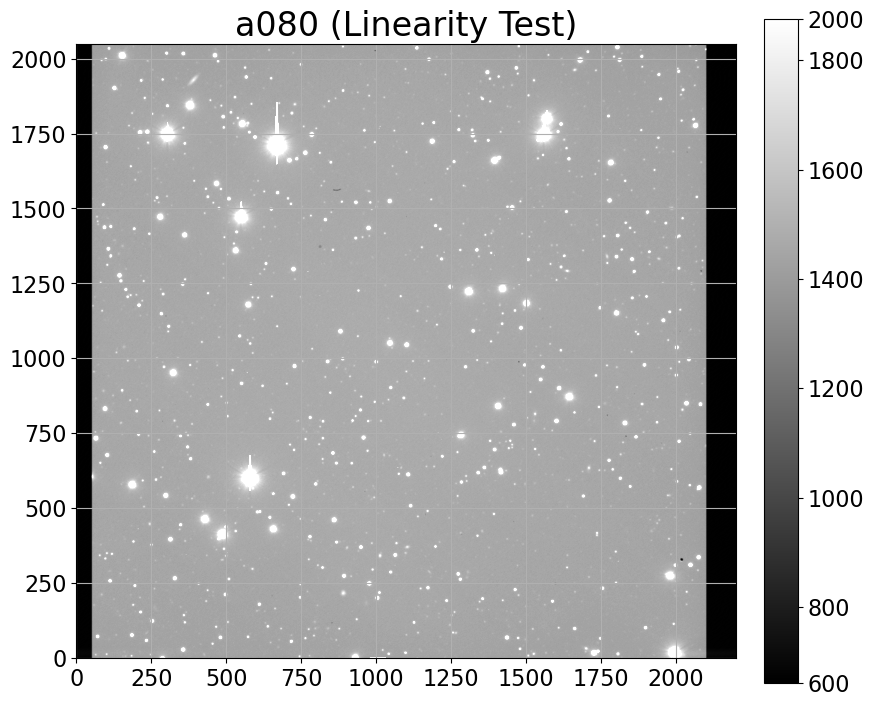

In [7]:
hdu = fits.open(data_dir+'a080.fits')
hdr = hdu[0].header
img_test = hdu[0].data
#fig = plt.subplots(1,1,figsize=(4,4))
show_image(img_test.data, cmap='gray')
plt.title('a080 (Linearity Test)')
plt.show()

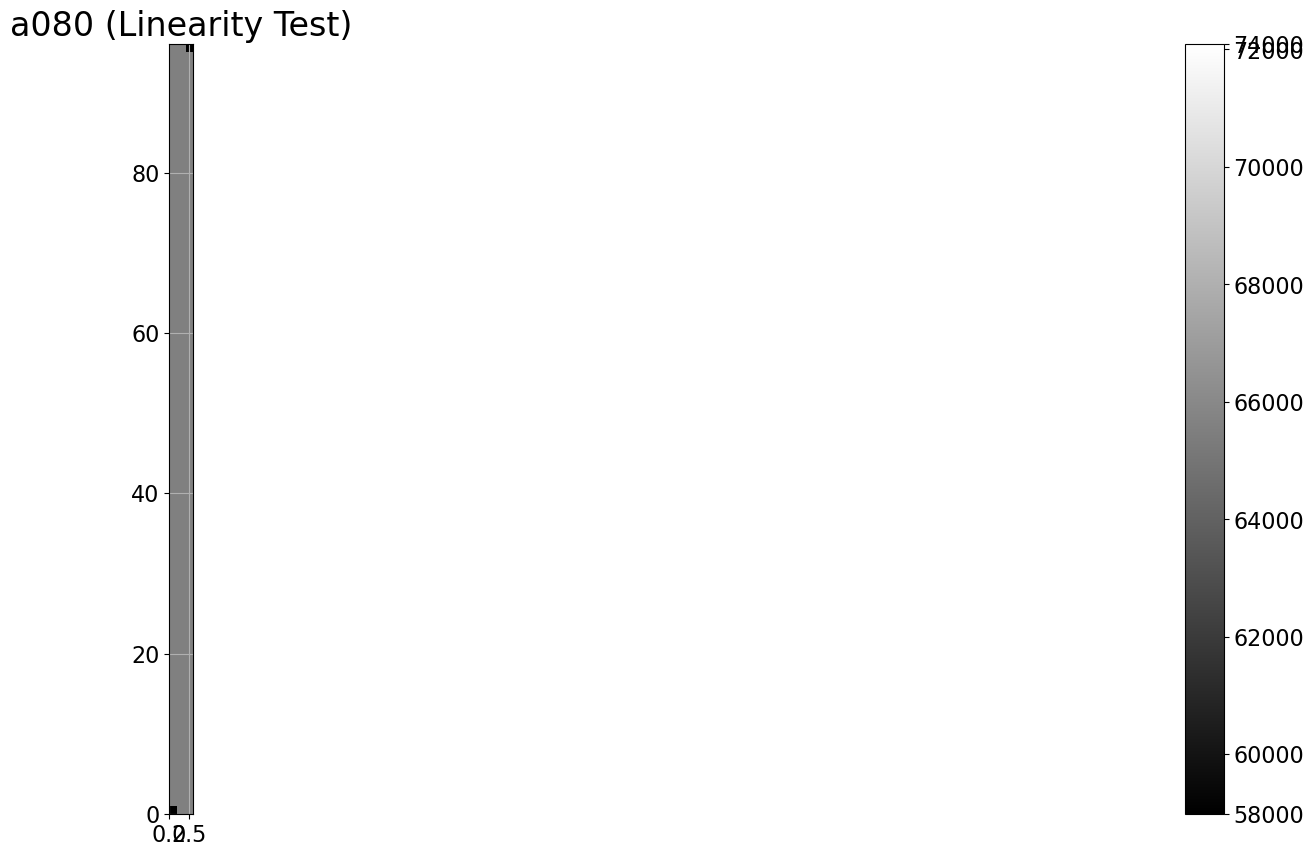

In [239]:
hdu = fits.open(data_dir+'a080.fits')
hdr = hdu[0].header
img_test = hdu[0].data
#fig = plt.subplots(1,1,figsize=(4,4))
show_image(img_test[567:663,578:581], cmap='gray')
plt.title('a080 (Linearity Test)')
plt.show()

*trying to grab a saturated star-HH

* [500:750,500:750]
* [590:750,1635:1870]
* [1500:1750,1700:1900]
* [1500:1550,1775:1785]
* [1524:1529,1775:1782]
* [1525:1528,1776:1781]
* [550:680,560:600]
* [560:675,575:585]
* [565:655,577:583]
* [565:655,577:582]
* [565:655,578:581]
* [557:675,577:582]

In [10]:
a080=CCDData.read(data_dir+'a080.fits', unit='adu')
a080[0].header['exptime']

128.0

In [240]:
#Linearity
line_mean=[]
line_exp=[]
for l in range(74,81):
    open_line=CCDData.read(f'Desktop/Obs_NB/Imaging/a0{l}.fits', unit='adu')
    img_line = ImageFileCollection(data_dir,glob_include=f'a0{l}.fits')
    line_mean.append(np.mean(open_line[567:663,578:581]))
    line_exp.append(img_line.summary['exptime'])

In [242]:
line_exp
line_mean
x=np.array([2,4,8,16,32,64,128])
y=np.array([1486.0520833333333, 1001.3715277777778, 1580.076388888889, 5627.034722222223, 10376.447916666666, 22435.309027777777, 65226.43402777778])

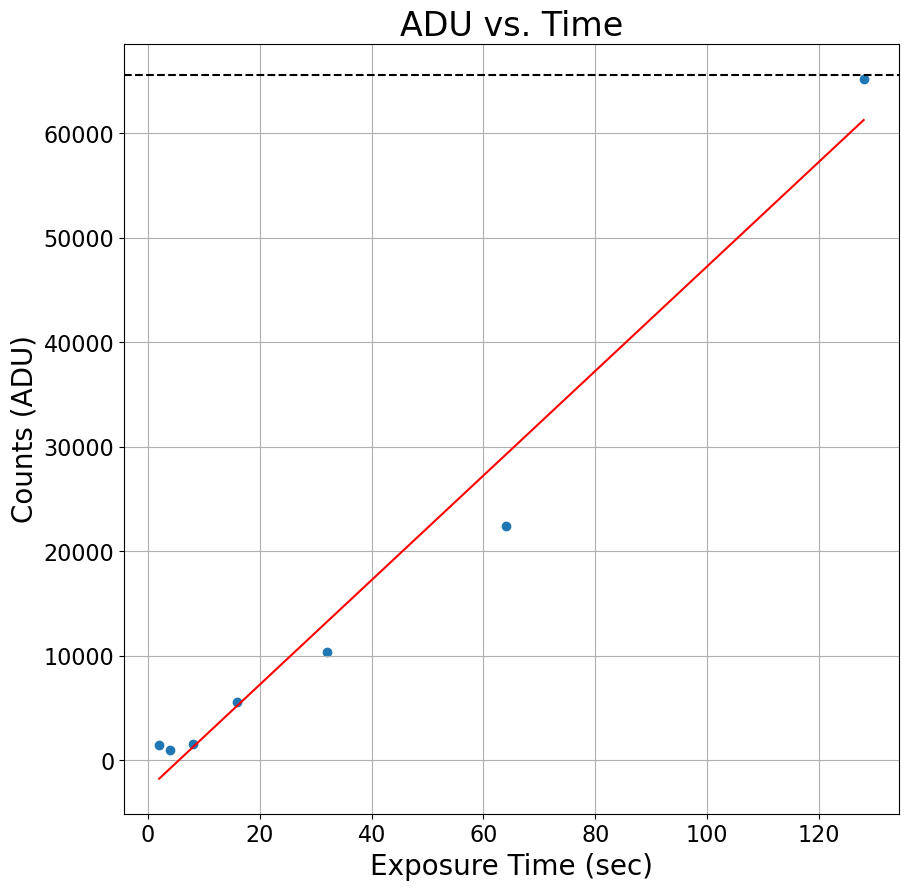

In [243]:
#plt.plot(line_exp, line_mean, linestyle='-.')
plt.scatter(line_exp, line_mean)

#xseq = np.linspace(2, 130, num=100)

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red') # Plot the fit line

plt.axhline(y = 65536, linestyle = '--', color='black')
plt.xlabel(r'Exposure Time (sec)')
plt.ylabel('Counts (ADU)')
plt.title('ADU vs. Time')

plt.show()

*As the exposure and ADU count increase, the data diverges more from the linear fit as the pixels begin to reach their limit for photon capacity-HH

## 2. Use photutils to perform aperture photometry on three (non saturated) stars in the PG1633+099 standard field: a really faint one, a medium bright one, and a bright one. 

Perform aperture photometry using at least 5 aperture sizes from very small to very large and make a plot that reproduces the one from Howell Figure 5.7 showing S/N as a function of aperture radius. What is a good aperture size to use for this dataset?

Text(0.5, 1.0, 'OTZF PG1633+099 (V_a085)')

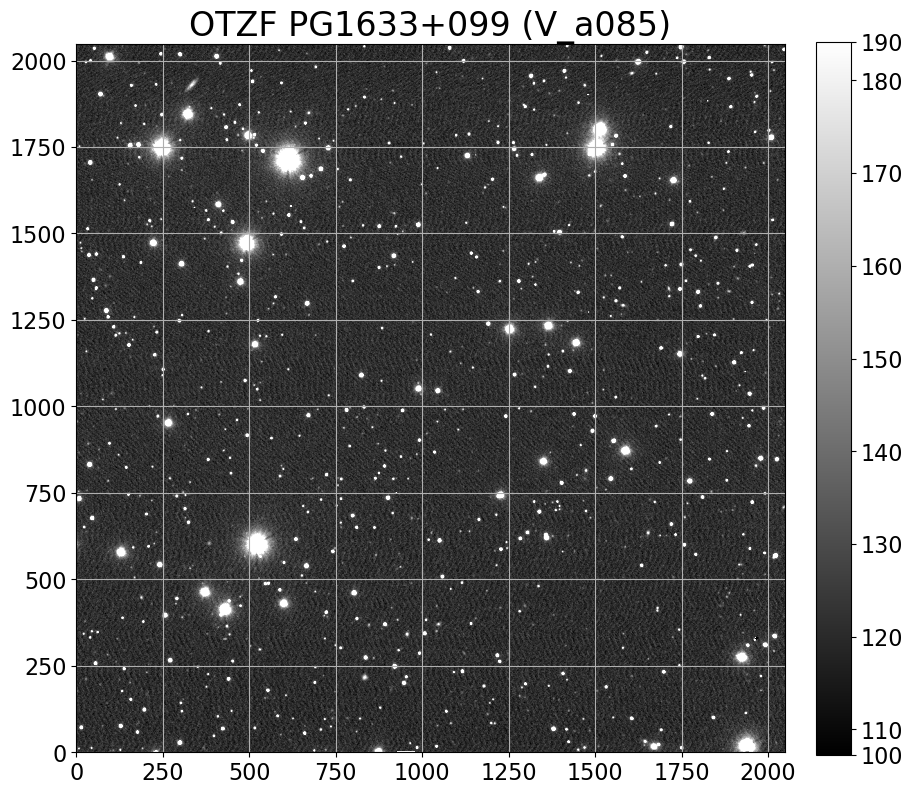

In [244]:
PG1=CCDData.read('Desktop/Obs_NB/reduced/otz_PG1633+099/otzf_PG1633_V/a085otzf.fits')
show_image(PG1.data, cmap='gray')
plt.rcParams["figure.figsize"] = (5,5)
plt.title('OTZF PG1633+099 (V_a085)')

In [245]:
faint_star=(272,264)
med_star=(1252,1225)
bright_star=(250,1750)
positions = [faint_star, med_star, bright_star]

In [246]:
from photutils.aperture import CircularAperture, CircularAnnulus
from photutils.aperture import aperture_photometry

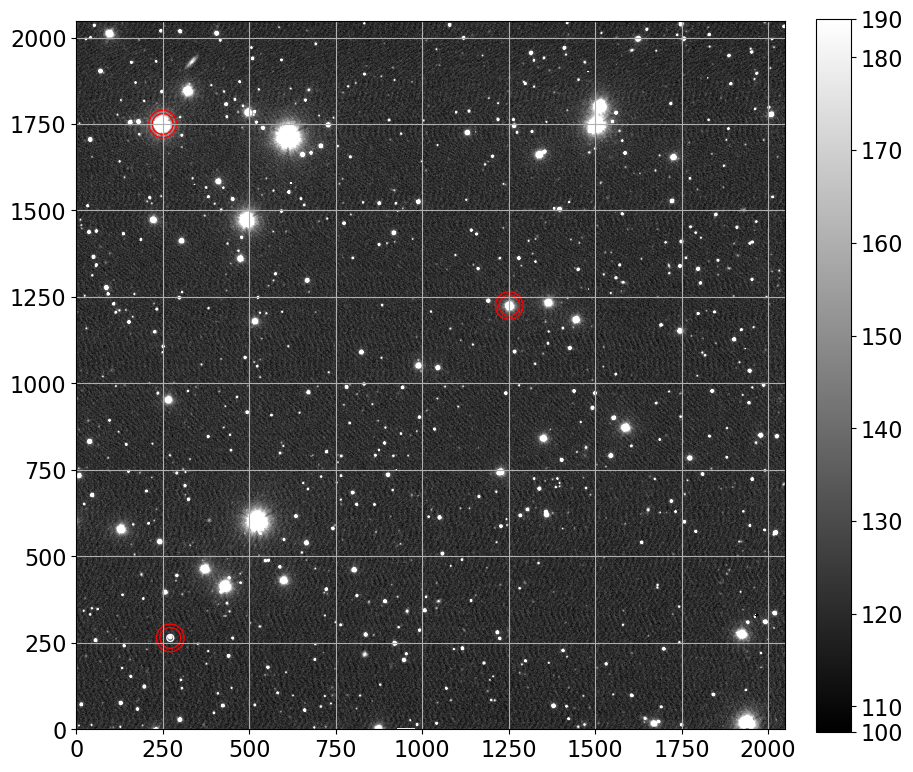

In [247]:
aperture = CircularAperture(positions, r=10)
annulus_aperture = CircularAnnulus(positions, r_in=30, r_out=40)

show_image(PG1.data, cmap='gray')
aperture.plot(edgecolor='white')
annulus_aperture.plot(edgecolor='red')

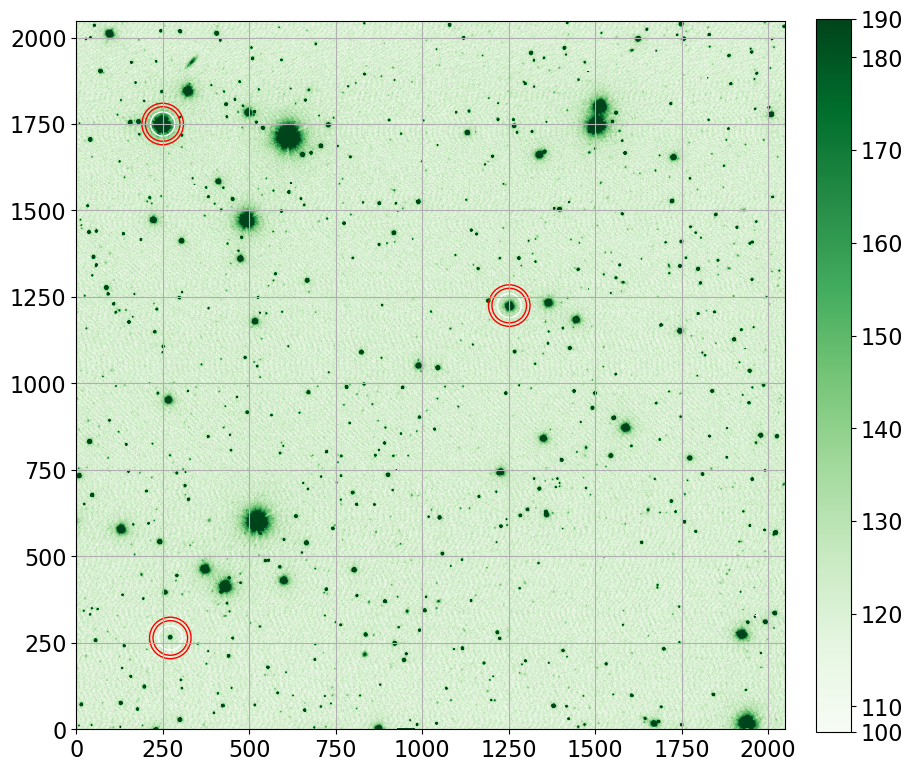

In [254]:
#Trying to get a clearer view of the stars
aperture = CircularAperture(positions, r=35)
annulus = CircularAnnulus(positions, r_in=50, r_out=60)

show_image(PG1.data, cmap='Greens')
aperture.plot(edgecolor='white')
annulus.plot(edgecolor='red')

*Following Photutils guide "Aperture Photometry" module -HH

In [255]:
aper_tab = aperture_photometry(PG1.data, aperture)
annu_tab = aperture_photometry(PG1.data, annulus)
print(aper_tab, annu_tab)

 id xcenter ycenter    aperture_sum   
      pix     pix                     
--- ------- ------- ------------------
  1   272.0   264.0  537183.7460279628
  2  1252.0  1225.0 1579747.9622837708
  3   250.0  1750.0  4804606.593617681  id xcenter ycenter    aperture_sum   
      pix     pix                     
--- ------- ------- ------------------
  1   272.0   264.0 418905.07456672355
  2  1252.0  1225.0 429348.84790251905
  3   250.0  1750.0  449407.4150667523


In [263]:
aper_tab = aperture_photometry(PG1.data, aperture)
for col in aper_tab.colnames:
    aper_tab[col].info.format = '%.8g'  # for consistent table output
print(aper_tab)

 id xcenter ycenter aperture_sum
      pix     pix               
--- ------- ------- ------------
  1     272     264    537183.75
  2    1252    1225      1579748
  3     250    1750    4804606.6


In [256]:
from photutils.aperture import ApertureStats
aperstats = ApertureStats(PG1.data, annulus)
bkg_mean = aperstats.mean
print(bkg_mean)

[121.23547447 124.12877767 130.05183912]


In [257]:
aperture.area

3848.4510006474966

In [258]:
aperture_area = aperture.area_overlap(PG1.data)
print(aperture_area)

[3848.45100065 3848.45100065 3848.45100065]


In [261]:
#total background within the circular aperture
total_bkg = bkg_mean * aperture_area
print(total_bkg)

[466568.78301946 477703.51864444 500498.13041208]


In [260]:
#background-subtracted photometry
phot_bkgsub = aper_tab['aperture_sum'] - total_bkg
print(phot_bkgsub)

   aperture_sum  
-----------------
70614.96300850488
1102044.443639332
4304108.463205604


In [264]:
aper_tab['total_bkg'] = total_bkg
aper_tab['aperture_sum_bkgsub'] = phot_bkgsub
for col in aper_tab.colnames:
    aper_tab[col].info.format = '%.8g'  # for consistent table output
print(aper_tab)

 id xcenter ycenter aperture_sum total_bkg aperture_sum_bkgsub
      pix     pix                                             
--- ------- ------- ------------ --------- -------------------
  1     272     264    537183.75 466568.78           70614.963
  2    1252    1225      1579748 477703.52           1102044.4
  3     250    1750    4804606.6 500498.13           4304108.5


### Perform aperture photometry using at least 5 aperture sizes from very small to very large and make a plot that reproduces the one from Howell Figure 5.7 showing S/N as a function of aperture radius. What is a good aperture size to use for this dataset?

(<matplotlib.patches.PathPatch at 0x30bdf6b50>,)

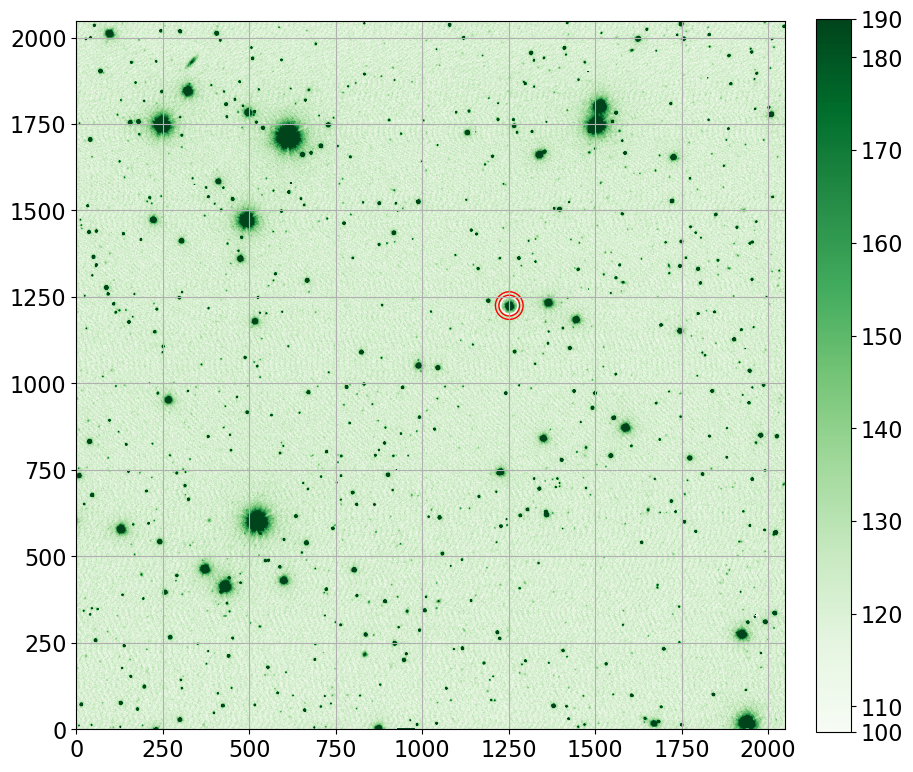

In [288]:
annulus_2 = CircularAnnulus(med_star, r_in=30, r_out=40)
aperture_1 = CircularAperture(med_star, r=25)

show_image(PG1.data, cmap='Greens')
aperture_1.plot(edgecolor='white')
annulus_2.plot(edgecolor='red')

In [301]:
radii = np.linspace(1,25,25)
apertures = [CircularAperture(med_star, r=r) for r in radii]
annulus_4 = CircularAnnulus(med_star, r_in=30, r_out=40)
phot_table = aperture_photometry(PG1.data, apertures)
for col in phot_table.colnames:
    phot_table[col].info.format = '%.8g'  # for consistent table output
print(phot_table)

 id xcenter ycenter ... aperture_sum_22 aperture_sum_23 aperture_sum_24
      pix     pix   ...                                                
--- ------- ------- ... --------------- --------------- ---------------
  1    1252    1225 ...       1299226.4       1318770.1       1339025.2


In [302]:
aperatures_area=[]
for i in apertures:
    i.area
    aperture_area = i.area_overlap(PG1.data)
    aperatures_area.append(aperture_area)
    #aper_tab = aperture_photometry(PG1.data, aps)
    #a=aper_tab['aperture_sum']
    #aper_tabs.append(a)
aperatures_area

[3.1415926535897927,
 12.566370614359172,
 28.274333882308138,
 50.26548245743669,
 78.53981633974485,
 113.09733552923257,
 153.93804002589985,
 201.06192982974676,
 254.46900494077326,
 314.1592653589793,
 380.13271108436504,
 452.38934211693027,
 530.929158456675,
 615.7521601035994,
 706.8583470577034,
 804.247719318987,
 907.9202768874502,
 1017.8760197630929,
 1134.1149479459154,
 1256.6370614359175,
 1385.442360233099,
 1520.53084433746,
 1661.9025137490007,
 1809.557368467721,
 1963.4954084936207]

In [303]:
aperstats = ApertureStats(PG1.data, annulus_4)
bkg_mean = aperstats.mean

In [304]:
total_bkgs=[]
for a in aperatures_area:
    total_bkg = a * bkg_mean
    total_bkgs.append(total_bkg)
total_bkgs

[395.7728557827327,
 1583.091423130931,
 3561.955702044595,
 6332.365692523724,
 9894.321394568322,
 14247.822808178382,
 19392.869933353904,
 25329.462770094895,
 32057.601318401357,
 39577.28557827328,
 47888.515549710675,
 56991.29123271353,
 66885.61262728184,
 77571.47973341562,
 89048.89255111487,
 101317.85108037958,
 114378.35532120976,
 128230.40527360541,
 142874.00093756654,
 158309.14231309315,
 174535.82940018518,
 191554.06219884267,
 209363.84070906564,
 227965.1649308541,
 247358.034864208]

In [305]:
aperature_sums=[]
for i in range(0,25): 
    l= phot_table[f'aperture_sum_{i}']
    aperature_sums.append(l)

In [319]:
snr=[]
for t,b, a in zip(aperature_sums, total_bkgs, aperatures_area):
    signal = t
    noise = np.sqrt(t+(b*a))
    sn = signal/ noise
    snr.append(sn)
snr

[<Column name='aperture_sum_0' dtype='float64' format='%.8g' length=1>
 151.98867,
 <Column name='aperture_sum_1' dtype='float64' format='%.8g' length=1>
 306.37931,
 <Column name='aperture_sum_2' dtype='float64' format='%.8g' length=1>
 456.44159,
 <Column name='aperture_sum_3' dtype='float64' format='%.8g' length=1>
 568.82271,
 <Column name='aperture_sum_4' dtype='float64' format='%.8g' length=1>
 608.32198,
 <Column name='aperture_sum_5' dtype='float64' format='%.8g' length=1>
 574.94153,
 <Column name='aperture_sum_6' dtype='float64' format='%.8g' length=1>
 501.55492,
 <Column name='aperture_sum_7' dtype='float64' format='%.8g' length=1>
 422.18465,
 <Column name='aperture_sum_8' dtype='float64' format='%.8g' length=1>
 352.81833,
 <Column name='aperture_sum_9' dtype='float64' format='%.8g' length=1>
 296.51599,
 <Column name='aperture_sum_10' dtype='float64' format='%.8g' length=1>
 251.73121,
 <Column name='aperture_sum_11' dtype='float64' format='%.8g' length=1>
 216.07733,
 <

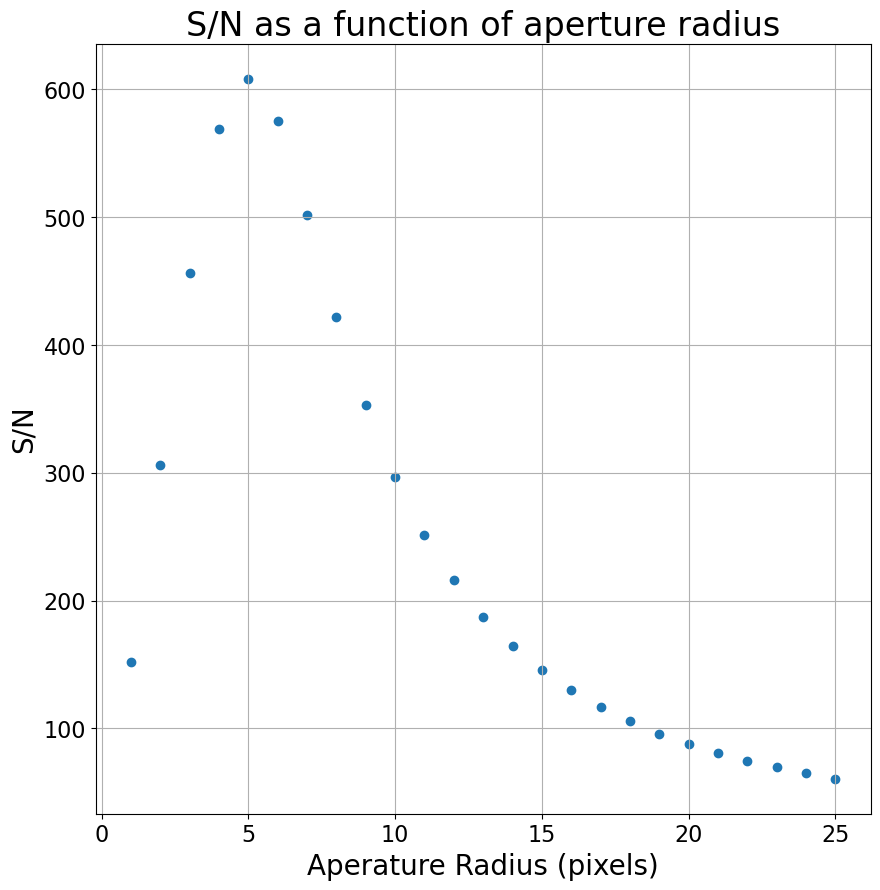

In [320]:
plt.figure(figsize=(10, 10))
plt.scatter(radii, snr)
plt.xlabel(r'Aperature Radius (pixels)')
plt.ylabel('S/N')
plt.title('S/N as a function of aperture radius')
plt.show()

*I'm unsure that I used the right eqn for s/n but the shape of the plot fits well with Howell's figure, granted the S/N value is much higher. Nonetheless, I think the aperature of 5 is our best bet -HH

## 3. Identify the standard stars in the PG1633+099 frame from Landolt (1992).

Text(0.5, 1.0, 'OTZF PG1633+099 (V_a085)')

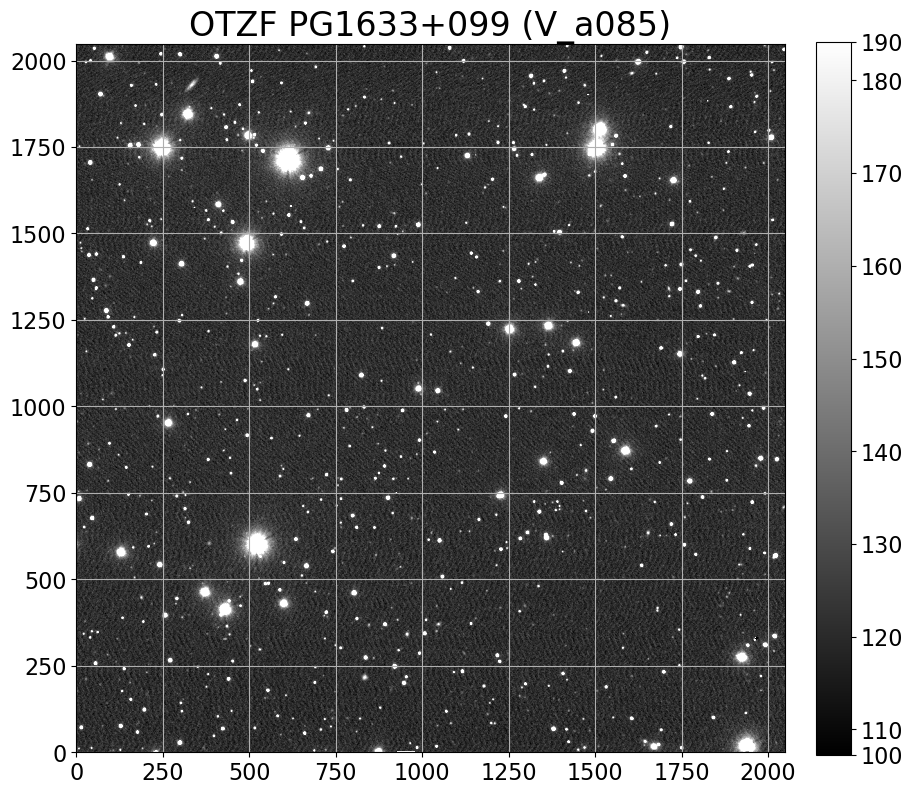

In [314]:
PG1=CCDData.read('Desktop/Obs_NB/reduced/otz_PG1633+099/otzf_PG1633_V/a085otzf.fits')
show_image(PG1.data, cmap='gray')
plt.rcParams["figure.figsize"] = (5,5)
plt.title('OTZF PG1633+099 (V_a085)')

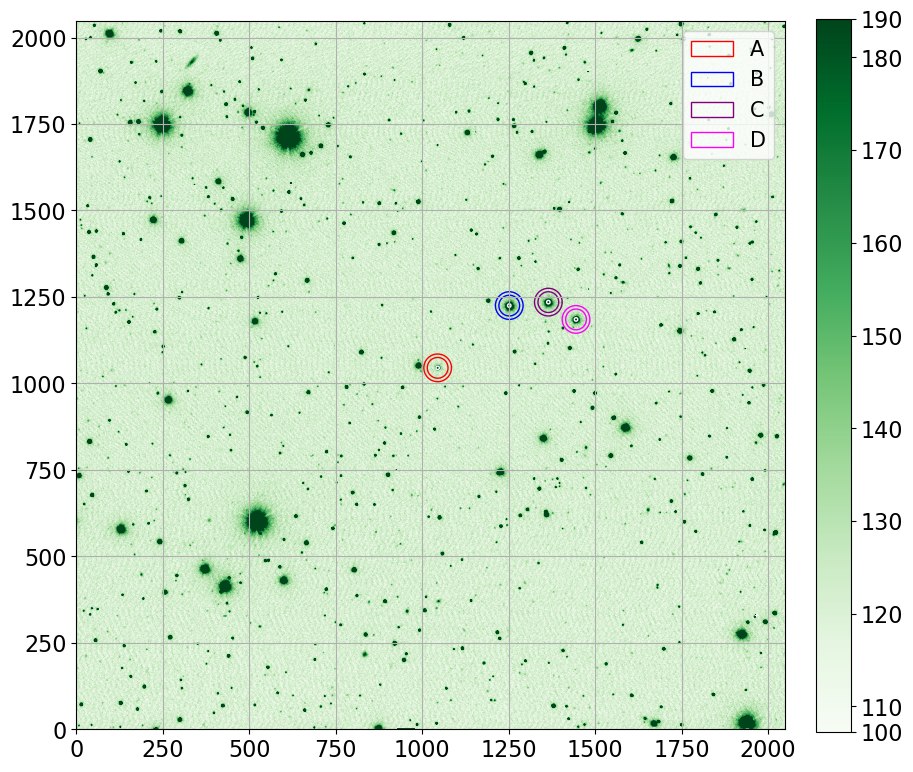

In [331]:
A=(1045,1045)
B=(1252,1225)
C=(1365,1235)
D=(1445,1185)
stan_star = [A,B,C,D]
colors = ['red', 'blue', 'purple', 'magenta']
stan_star_name = ['A','B','C','D']

aperture = CircularAperture(stan_star, r=5)
annulus = CircularAnnulus(stan_star, r_in=30, r_out=40)

show_image(PG1.data, cmap='Greens')
aperture.plot(edgecolor='white')
for i in range(4):
    name=stan_star_name[i]
    annulus[i].plot(edgecolor=colors[i], label=name
                   )
plt.legend(fontsize='small', prop={'size': 15})

*The photo in Landolt needs to be turn upside down, but its a match -HH

## 4. Extract instrumental magnitudes for all of your standard stars using an approach that you’ve advocated for as best you can in the questions above.

In [332]:
#getting pixel adu sum in aperture and annulus
ape_table = aperture_photometry(PG1.data, aperture)
ann_table = aperture_photometry(PG1.data, annulus)
print(ape_table, ann_table)

 id xcenter ycenter    aperture_sum   
      pix     pix                     
--- ------- ------- ------------------
  1  1045.0  1045.0  124788.3708586098
  2  1252.0  1225.0  752306.2723085622
  3  1365.0  1235.0 508142.40212441585
  4  1445.0  1185.0  445035.2969059138  id xcenter ycenter    aperture_sum   
      pix     pix                     
--- ------- ------- ------------------
  1  1045.0  1045.0  269954.9966125223
  2  1252.0  1225.0 276982.55942726956
  3  1365.0  1235.0  275694.6251754459
  4  1445.0  1185.0  272872.0344058728


In [333]:
#getting area of annulus and aperture
ape_area = np.pi*(5**2)
ann_area = np.pi*(40**2 - 30**2)
print(ape_area, ann_area)

78.53981633974483 2199.114857512855


In [334]:
bg_counts=[]
aperture_sums=[]
for i in range(4):
    bg_count = float(ann_table['aperture_sum'][i])/ann_area
    bg_counts.append(bg_count)
    aprert=ape_table['aperture_sum'][i]
    aperture_sums.append(aprert)
bg_counts

[122.75620606639653,
 125.95183852312746,
 125.36617823011291,
 124.08266602067542]

In [337]:
ins_mags=[]
for a,b in zip(aperture_sums, bg_counts):
    inst_mag = -2.5*np.log(a - ape_area*b)
    ins_mags.append(inst_mag)
ins_mags

[-29.134914756469872,
 -33.79415592319412,
 -32.797374722746056,
 -32.459418623283355]

## 5. Plot your standard star instrumental magnitudes versus their airmass (or since you have many diﬀerent standard stars taken at diﬀerent airmass, plot the diﬀerence between the accepted magnitude and your instrumental magnitude versus airmass). 
Use one of the linear fitting routines in Python to do a least squares fit to find and plot the extinction coeﬃcients at each filter. You can find their magnitudes and colors in Landolt (1992).

$$
M=m_{inst}-kx
$$

### I fil

In [801]:
ins_mag_089=np.array([-27.539170716983648, -31.478606988904442, -29.556608949910412, -28.52317114289142])
ins_mag_090=np.array([-28.3681758294215, -32.97134098441735, -31.720975232966197, -30.40992898057059])
ins_mag_138=np.array([-28.74525126428813, -32.713902732259946, -31.618634493595547, -31.445570636694065])
ins_mag_210=np.array([-20.169848977041504, -23.537900409752197, -28.309847308085164, -21.618988355136697])
ins_mag_245=np.array([-28.297770680143508, -33.59221111937653, -33.016254035651805, -31.04873059859458])

In [802]:
r_i=np.array([0.511, 0.502, 0.523, 0.327])
def mag_dif_i(i,l, vr, ri):
    r=l-vr
    i_fill=r-ri
    m = i_fill-i
    return m

In [803]:
master_magi=np.concatenate((mag_dif_i(ins_mag_089,land_mags, v_r, r_i), mag_dif_i(ins_mag_090,land_mags, v_r, r_i), mag_dif_i(ins_mag_138,land_mags, v_r, r_i), mag_dif_i(ins_mag_210,land_mags, v_r, r_i), mag_dif_i(ins_mag_245,land_mags, v_r, r_i)))
airmassi=np.concatenate(([1.18]*4, [1.17]*4, [1.24]*4, [1.53]*4, [2.26]*4))

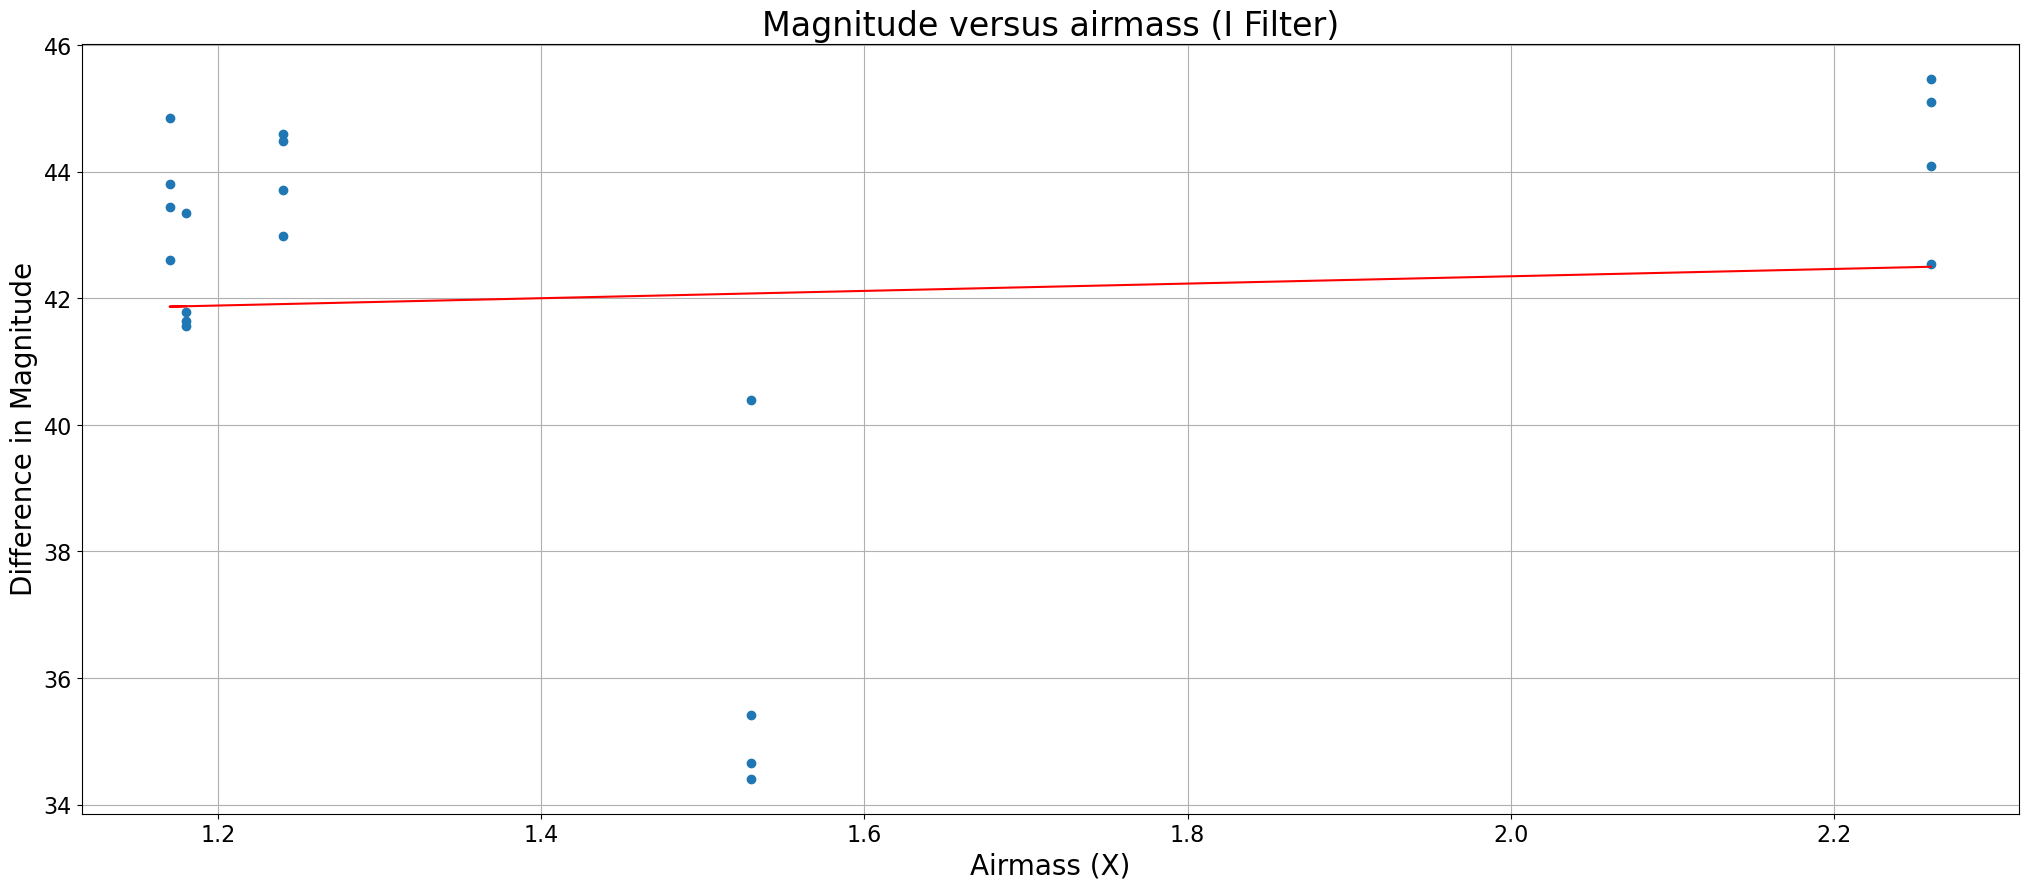

In [805]:
plt.figure(figsize=(25, 10))
plt.scatter(airmassi, master_magi)
mi, b = np.polyfit(airmassi, master_magi, 1)
plt.plot(airmassi, mi*airmassi + b, color='red') # Plot the fit line
plt.xlabel(r'Airmass (X)')
plt.ylabel('Difference in Magnitude')
plt.title('Magnitude versus airmass (I Filter)')
plt.show()

In [806]:
mi

0.5777309425323381

### R fil

In [770]:
ins_mag_087=np.array([-28.427816404790185, -32.877138108991176, -31.65910360677841, -30.928536887297263])
ins_mag_136=np.array([-28.720305052093032, -34.19325769281151, -33.64818671155255, -31.98534993330999])
ins_mag_208=np.array([-23.64522400904424, -26.900424007792086, -25.390792762455213, -25.98017225005929])
ins_mag_243=np.array([-24.325179047877718, -28.764670449127827, -26.017975847674265, -26.106063900567197])
ins_mag_244=np.array([-28.194162872112013, -33.17643044633256, -32.45853217706313, -31.30421860933625])

In [772]:
v_r=np.array([0.505, 0.590, 0.618, 0.324])
def mag_dif_r(i,v,vr):
    r=v-vr
    m = r-i
    return m

In [773]:
master_magr=np.concatenate((mag_dif_r(ins_mag_087,land_mags, v_r), mag_dif_r(ins_mag_136,land_mags, v_r), mag_dif_r(ins_mag_208,land_mags, v_r), mag_dif_r(ins_mag_243,land_mags, v_r), mag_dif_r(ins_mag_244,land_mags, v_r)))
airmassr=np.concatenate(([1.18]*4, [1.24]*4, [1.53]*4, [2.23]*4, [2.23]*4))

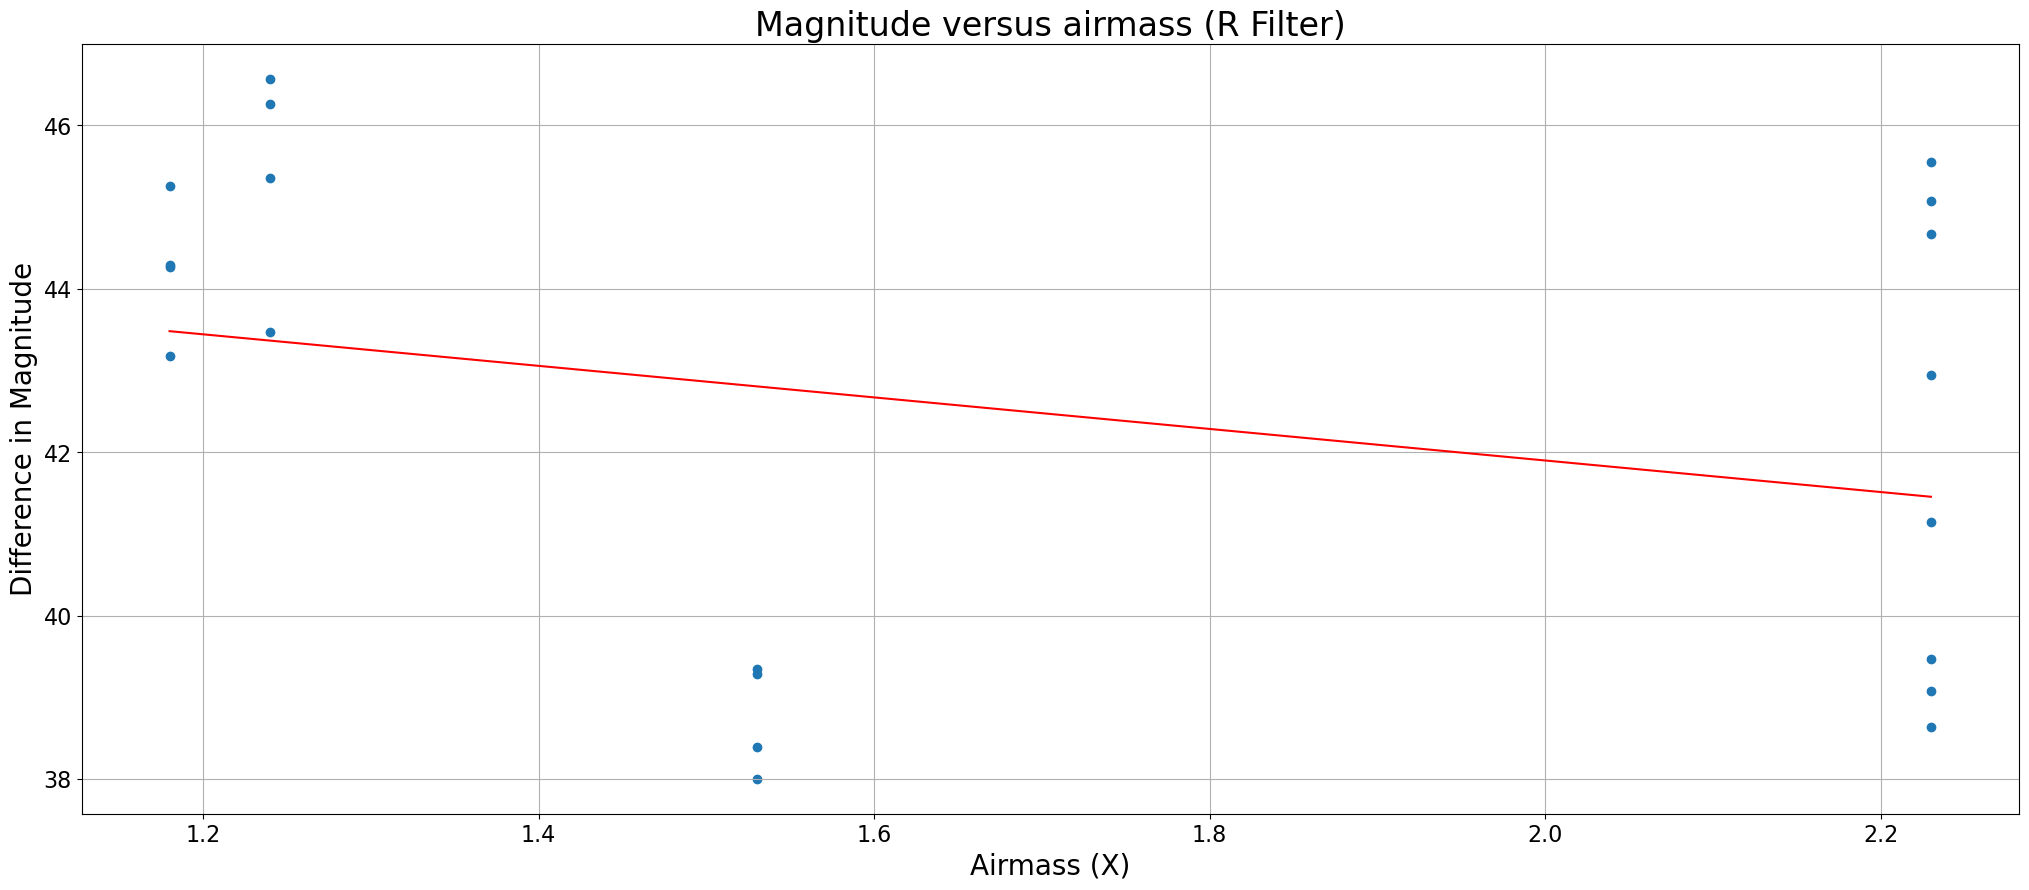

In [774]:
plt.figure(figsize=(25, 10))
plt.scatter(airmassr, master_magr)
mr, b = np.polyfit(airmassr, master_magr, 1)
plt.plot(airmassr, mr*airmassr + b, color='red') # Plot the fit line
plt.xlabel(r'Airmass (X)')
plt.ylabel('Difference in Magnitude')
plt.title('Magnitude versus airmass (R Filter)')
plt.show()

In [775]:
mr

-1.9309813293201123

### B fil

In [729]:
ins_mag_083=np.array([-27.80879325613437, -31.291192515950907, -29.876809996473295, -31.238550294275754])
ins_mag_132=np.array([-27.945654173365373, -32.736981290877836, -32.03078419761553, -32.2529396766403])
ins_mag_133=np.array([-28.035104824929135, -32.69491456507363, -31.99285773340296, -32.220795904596464])
ins_mag_204=np.array([-24.325179047877718, -28.764670449127827, -26.017975847674265, -26.106063900567197])
ins_mag_239=np.array([-27.326578139648152, -32.226032527137605, -31.537788112370592, -31.769114290915574])

In [731]:
b_v=np.array([0.873, 1.081, 1.134, 0.535])
def mag_dif_b(i,l, c):
    b=c+l
    m = b-i
    return m

In [733]:
master_magb=np.concatenate((mag_dif_b(ins_mag_083,land_mags, b_v), mag_dif_b(ins_mag_132,land_mags, b_v), mag_dif_b(ins_mag_133,land_mags, b_v), mag_dif_b(ins_mag_204,land_mags, b_v), mag_dif_b(ins_mag_239,land_mags, b_v)))
airmassb=np.concatenate(([1.18]*4, [1.24]*4, [1.51]*4, [1.51]*4, [2.9]*4))

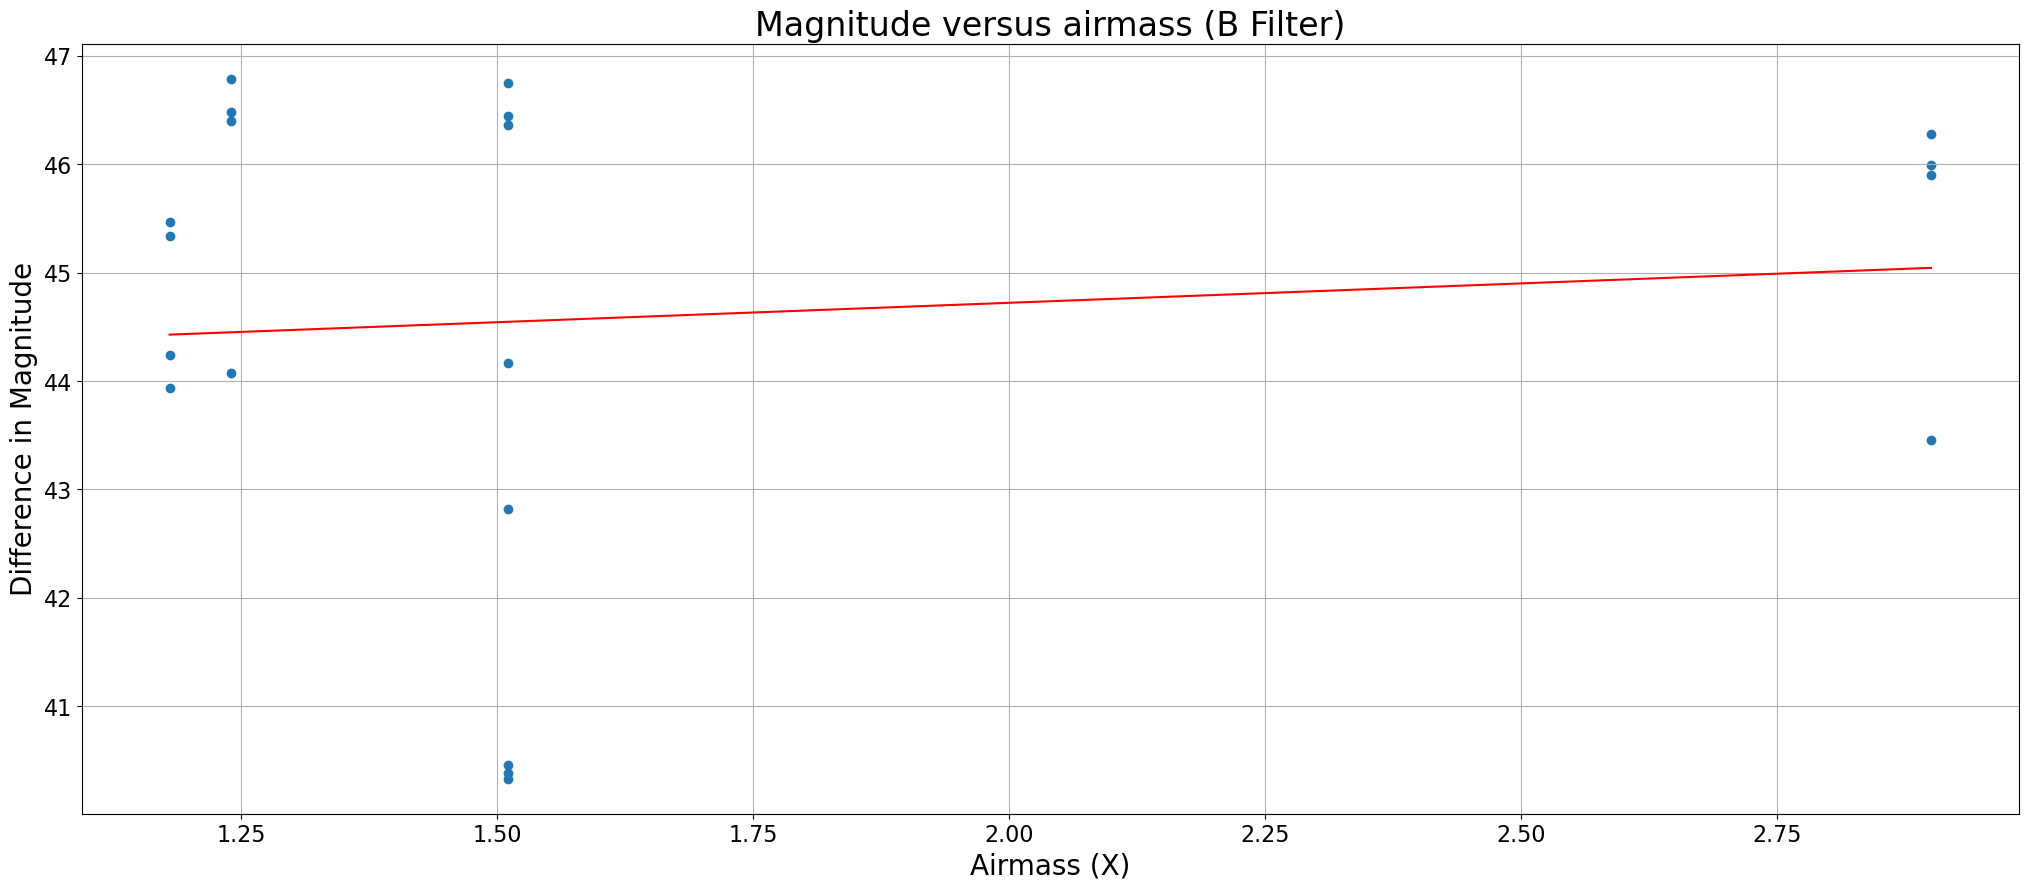

In [735]:
plt.figure(figsize=(25, 10))
plt.scatter(airmassb, master_magb)
mb, b = np.polyfit(airmassb, master_magb, 1)
plt.plot(airmassb, mb*airmassb + b, color='red') # Plot the fit line
plt.xlabel(r'Airmass (X)')
plt.ylabel('Difference in Magnitude')
plt.title('Magnitude versus airmass (B Filter)')
plt.show()

In [736]:
mb

0.3578707980089391

### U fil

In [740]:
ins_mag_082=np.array([-26.710876678369697, -32.120505104016445, -31.56472872063993, -30.656652546086768])
ins_mag_130=np.array([-26.83598108702361, -32.05109984386275, -31.331633510566913, -30.608198642385666])
ins_mag_131=np.array([-26.83598108702361, -32.05109984386275, -31.331633510566913, -30.608198642385666])
ins_mag_202=np.array([-26.83598108702361, -32.05109984386275, -31.331633510566913, -30.608198642385666])
ins_mag_203=np.array([-26.83598108702361, -32.05109984386275, -31.331633510566913, -30.608198642385666])

In [742]:
u_b=np.array([0.320, 1.007, 1.138, -0.025])

def mag_dif_u(i,l, bv, ub):
    b=bv+l
    u=b+ub
    m = u-i
    return m

In [743]:
master_magu=np.concatenate((mag_dif_u(ins_mag_082,land_mags, b_v, u_b), mag_dif_u(ins_mag_130,land_mags, b_v, u_b), mag_dif_u(ins_mag_131,land_mags, b_v, u_b),mag_dif_u(ins_mag_202,land_mags, b_v, u_b), mag_dif_u(ins_mag_203,land_mags, b_v, u_b)))
airmassu=np.concatenate(([1.18]*4, [1.23]*4, [1.24]*4, [1.49]*4, [1.49]*4))

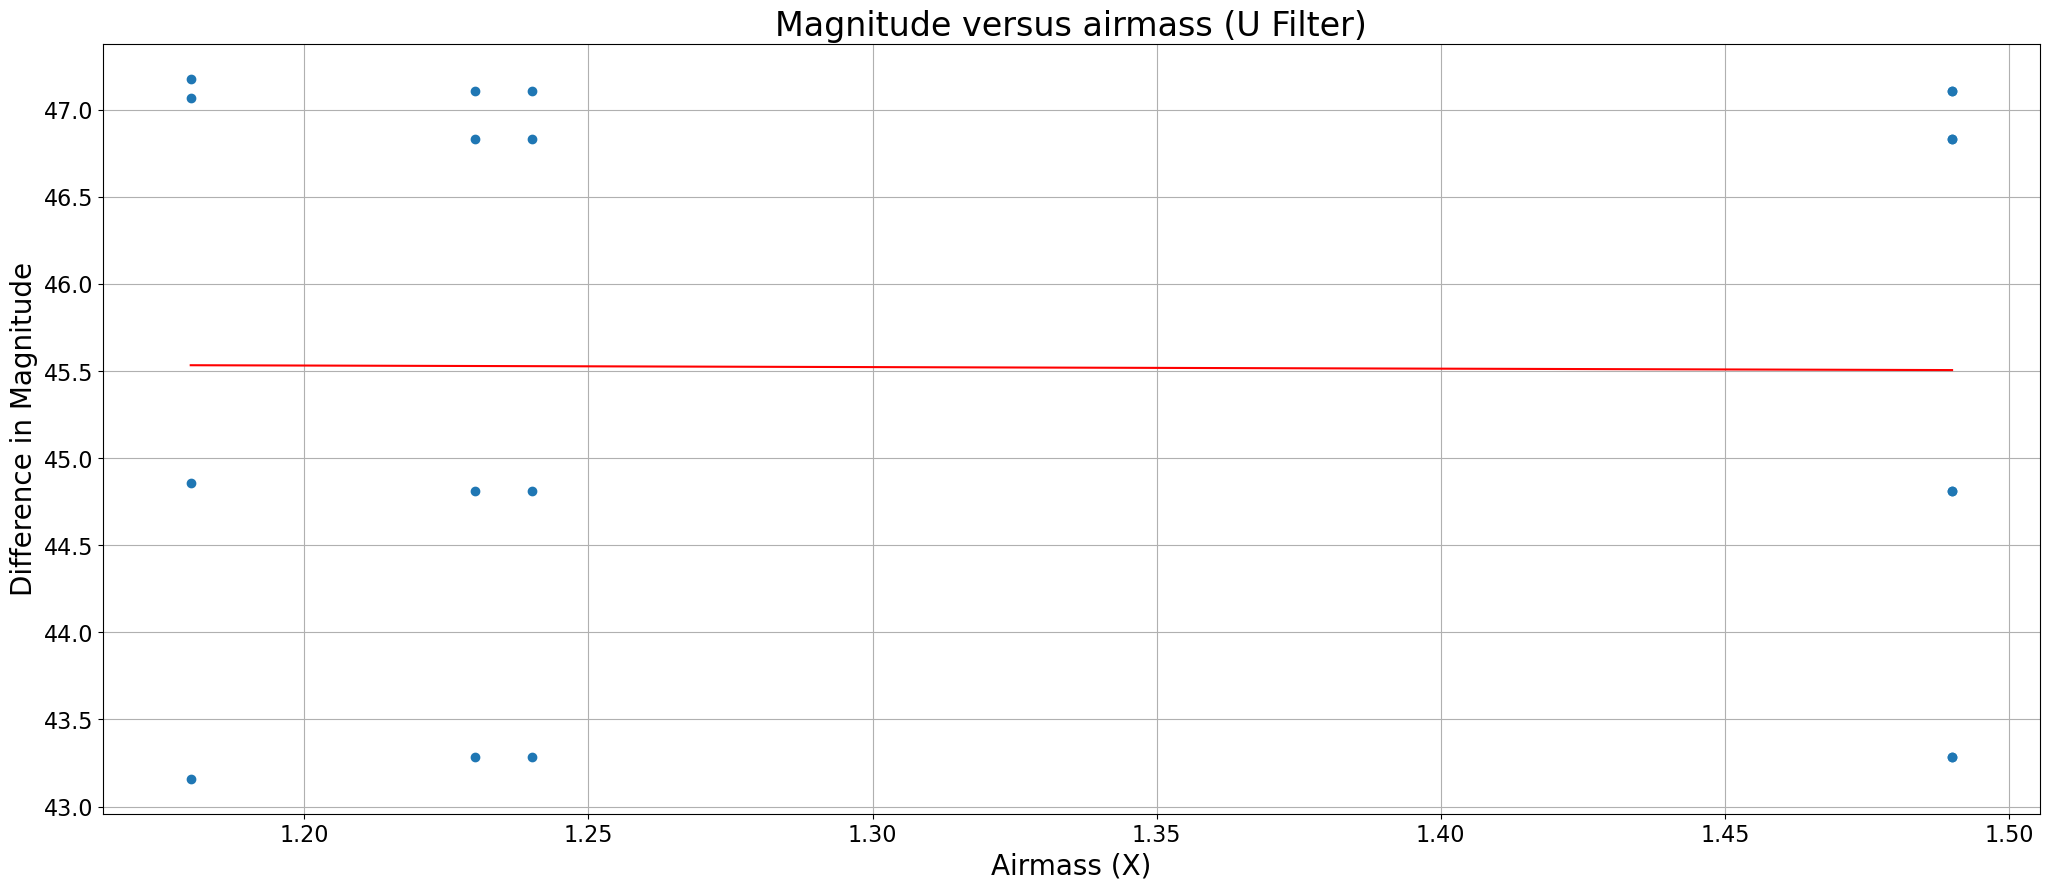

In [744]:
plt.figure(figsize=(25, 10))
plt.scatter(airmassu, master_magu)
mu, b = np.polyfit(airmassu, master_magu, 1)
plt.plot(airmassu, mu*airmassu + b, color='red') # Plot the fit line
plt.xlabel(r'Airmass (X)')
plt.ylabel('Difference in Magnitude')
plt.title('Magnitude versus airmass (U Filter)')
plt.show()

In [745]:
mu

-0.08987705770276343

### V fil

In [642]:
 ins_mags

[-27.303699461736723,
 -32.68862463333833,
 -31.127198950945072,
 -30.977225564624785]

In [652]:
ins_mag_206=np.array([-27.45038568318826, -32.64484373309682, -32.05639559852245, -31.045444224116288])
ins_mag_074=np.array([-21.164471338216906, -27.933358881957652, -27.235511826270677, -26.317372961045194])
ins_mag_085=np.array([-28.827874104875256, -32.82163865356277, -31.38232617873332, -31.581172431892686])
ins_mag_134=np.array([-27.303699461736723, -32.68862463333833, -31.127198950945072, -30.977225564624785])
ins_mag_241=np.array([-27.303699461736723, -32.68862463333833, -31.127198950945072, -30.977225564624785])

In [653]:
land_mags=[15.256, 12.969, 13.229, 13.691]
def mag_dif_v(i,l):
    m = l-i
    return m

In [678]:
master_magv=np.concatenate((mag_dif_v(ins_mag_074,land_mags), mag_dif_v(ins_mag_085,land_mags), mag_dif_v(ins_mag_134,land_mags),mag_dif_v(ins_mag_206,land_mags), mag_dif_v(ins_mag_241,land_mags)))
airmassv=np.concatenate(([1.19]*4, [1.18]*4, [1.24]*4, [1.52]*4, [2.21]*4))

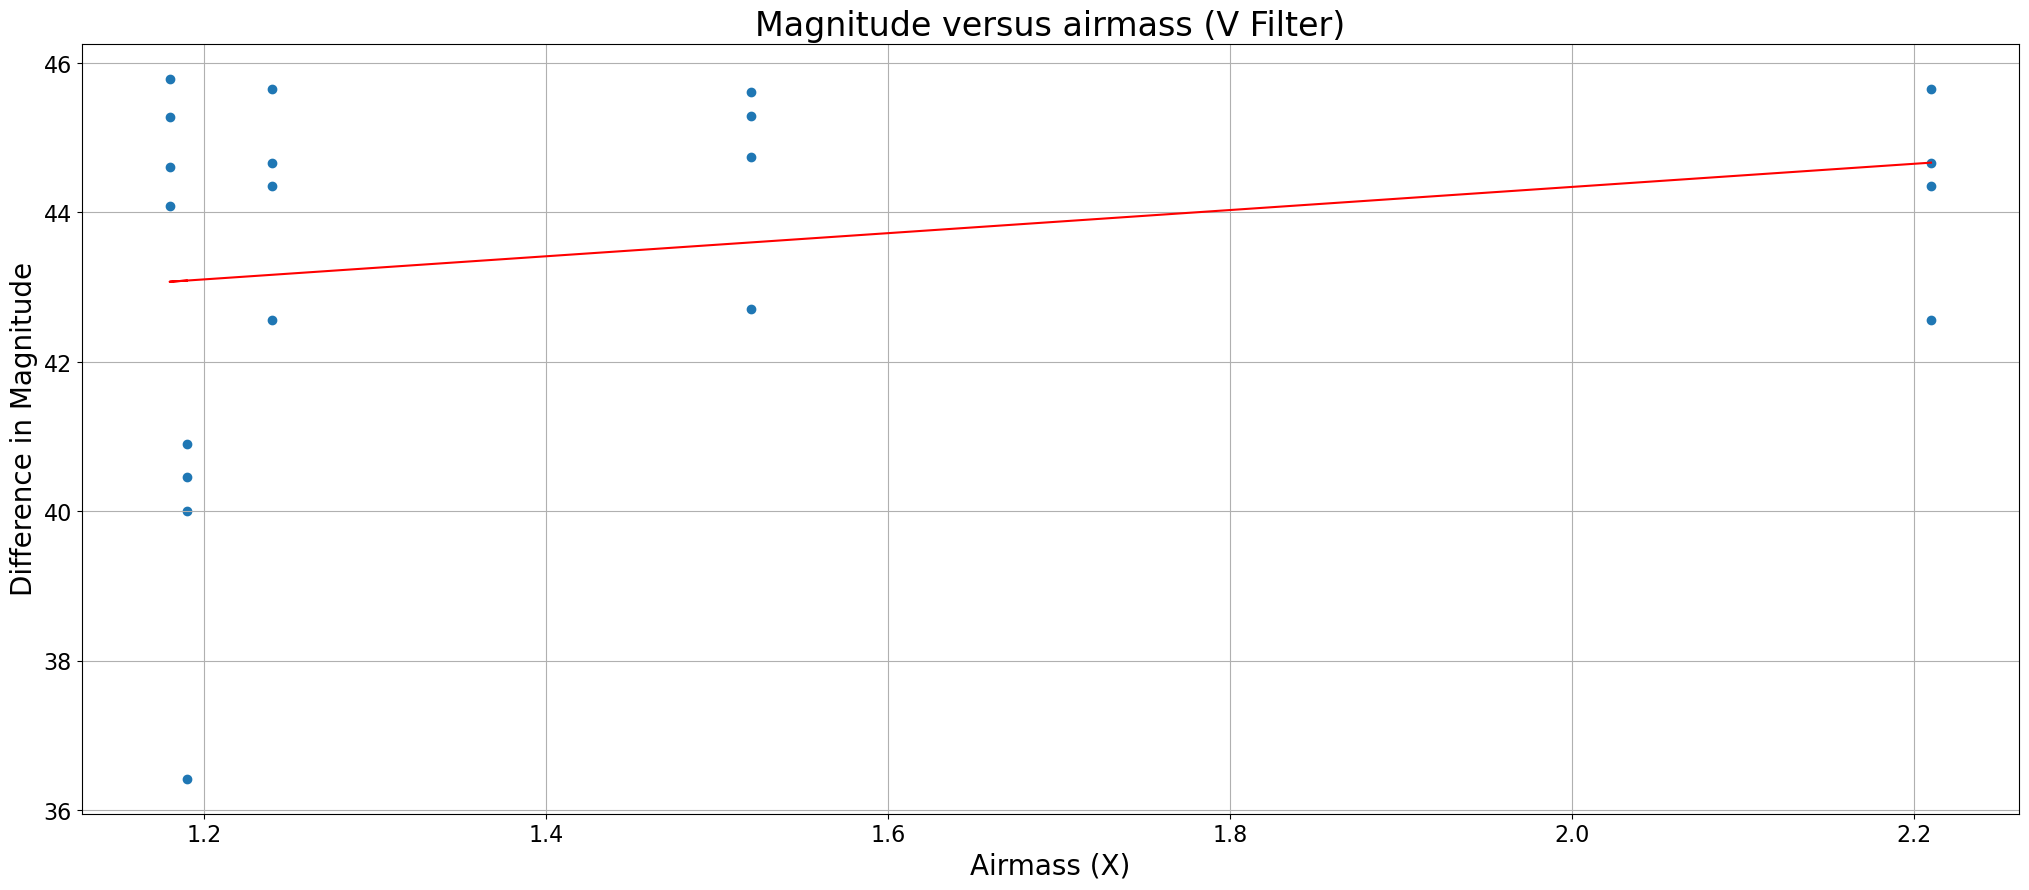

In [679]:
plt.figure(figsize=(25, 10))
plt.scatter(airmassv, master_magv)
m, b = np.polyfit(airmassv, master_magv, 1)
plt.plot(airmassv, m*airmassv + b, color='red') # Plot the fit line
plt.xlabel(r'Airmass (X)')
plt.ylabel('Difference in Magnitude')
plt.title('Magnitude versus airmass (V Filter)')
plt.show()

In [680]:
m

1.5475683035228747

*I know that the extinction coefficient is supposed to be the slope, but I feel like these k values aren't quite right. Something likely went wrong with my equations/axes. These values are better than what I got in previous attempts, so I'm going to go with these, but the error will likely propagate -HH

## Q5 Scraps/different approach

*In order to find the airmasses I am going to follow along with the approach we used in coordinates notes from class. I am going to use information from Landolt 1992, assuming that the observed with CTIO, I need to use the latitude of telescope and the declination listed for each standard star -HH

### V filter

In [366]:
def x_min(lat, d, m, s):
    deg=d+(m/60)+(s/3600)
    z_min=lat+deg
    x_min=1/np.cos(np.radians(z_min))
    return x_min

In [407]:
a_x=x_min(30.168, 9, 47, 48)
b_x=x_min(30.168, 9, 46, 17)
c_x=x_min(30.168, 9, 46, 11)
d_x=x_min(30.168, 9, 46, 38)

In [408]:
airmass=[a_x, b_x, c_x, d_x]

In [409]:
airmass

[1.0667164212470013,
 1.0668913056815215,
 1.0669028458363077,
 1.0668509242144373]

In [338]:
lan_mags=[15.256, 12.969, 13.229, 13.691]

In [426]:
mags=[]
for i,l in zip(ins_mags, lan_mags):
    m = l-i
    mags.append(m)

In [427]:
mags

[44.39091475646987, 46.76315592319412, 46.026374722746056, 46.15041862328336]

In [477]:
airmass
x=np.array([1.0667164212470013,1.0668913056815215,1.0669028458363077,1.0668509242144373])
y=np.array([44.39091475646987, 46.76315592319412, 46.026374722746056, 46.15041862328336])

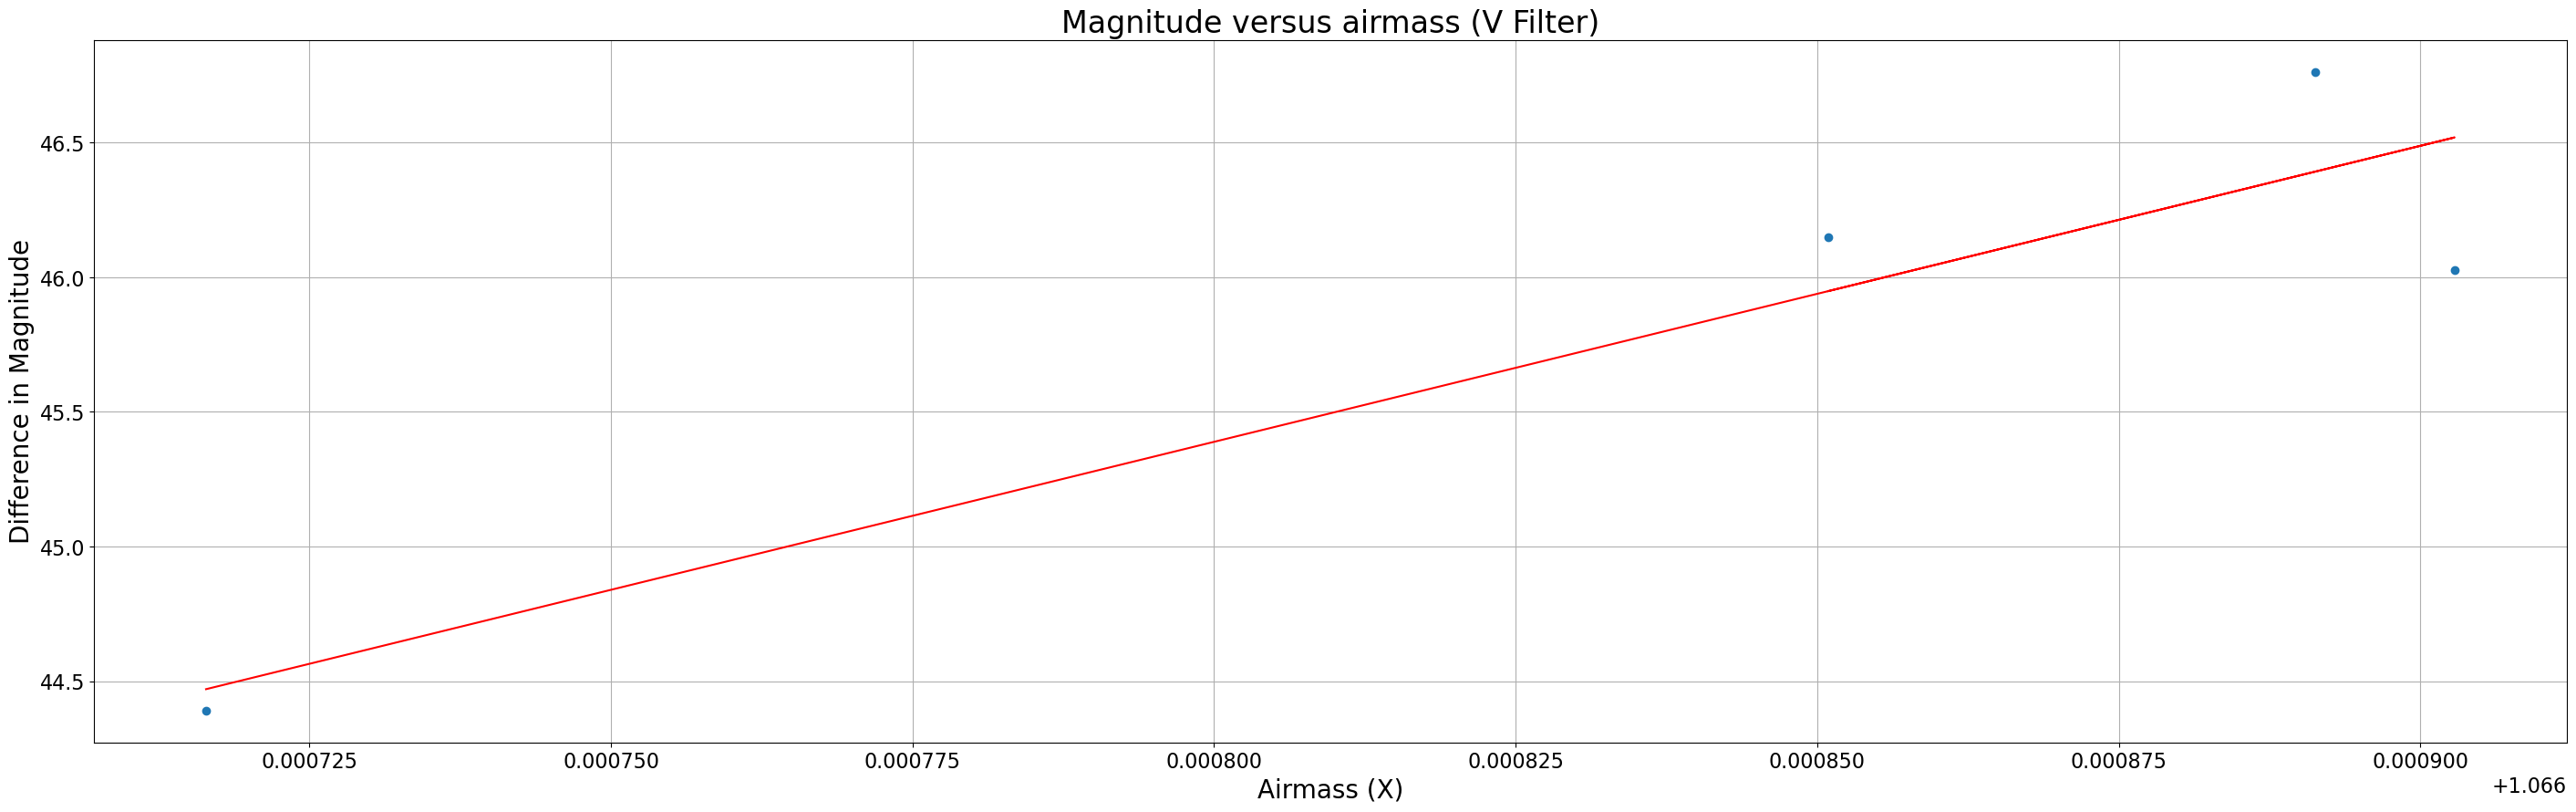

In [481]:
plt.figure(figsize=(35, 10))
plt.scatter(airmass, mags)
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red') # Plot the fit line
plt.xlabel(r'Airmass (X)')
plt.ylabel('Difference in Magnitude')
plt.title('Magnitude versus airmass (V Filter)')
plt.show()

In [479]:
m

10993.54672936923

### B filter

In [504]:
ins_mags_b_v=np.array([-27.80879325613437,-31.291192515950907, -29.876809996473295,-31.238550294275754])

In [524]:
b_v=np.array([0.873, 1.081, 1.134, 0.535])
mags_b=[]
bm=[]
for i,l,c in zip(ins_mags_b_v, lan_mags, b_v):
    b=c+l
    bm.append(b)
    m = b-i
    mags_b.append(m)

In [525]:
mags_b

[43.93779325613437, 45.34119251595091, 44.2398099964733, 45.46455029427575]

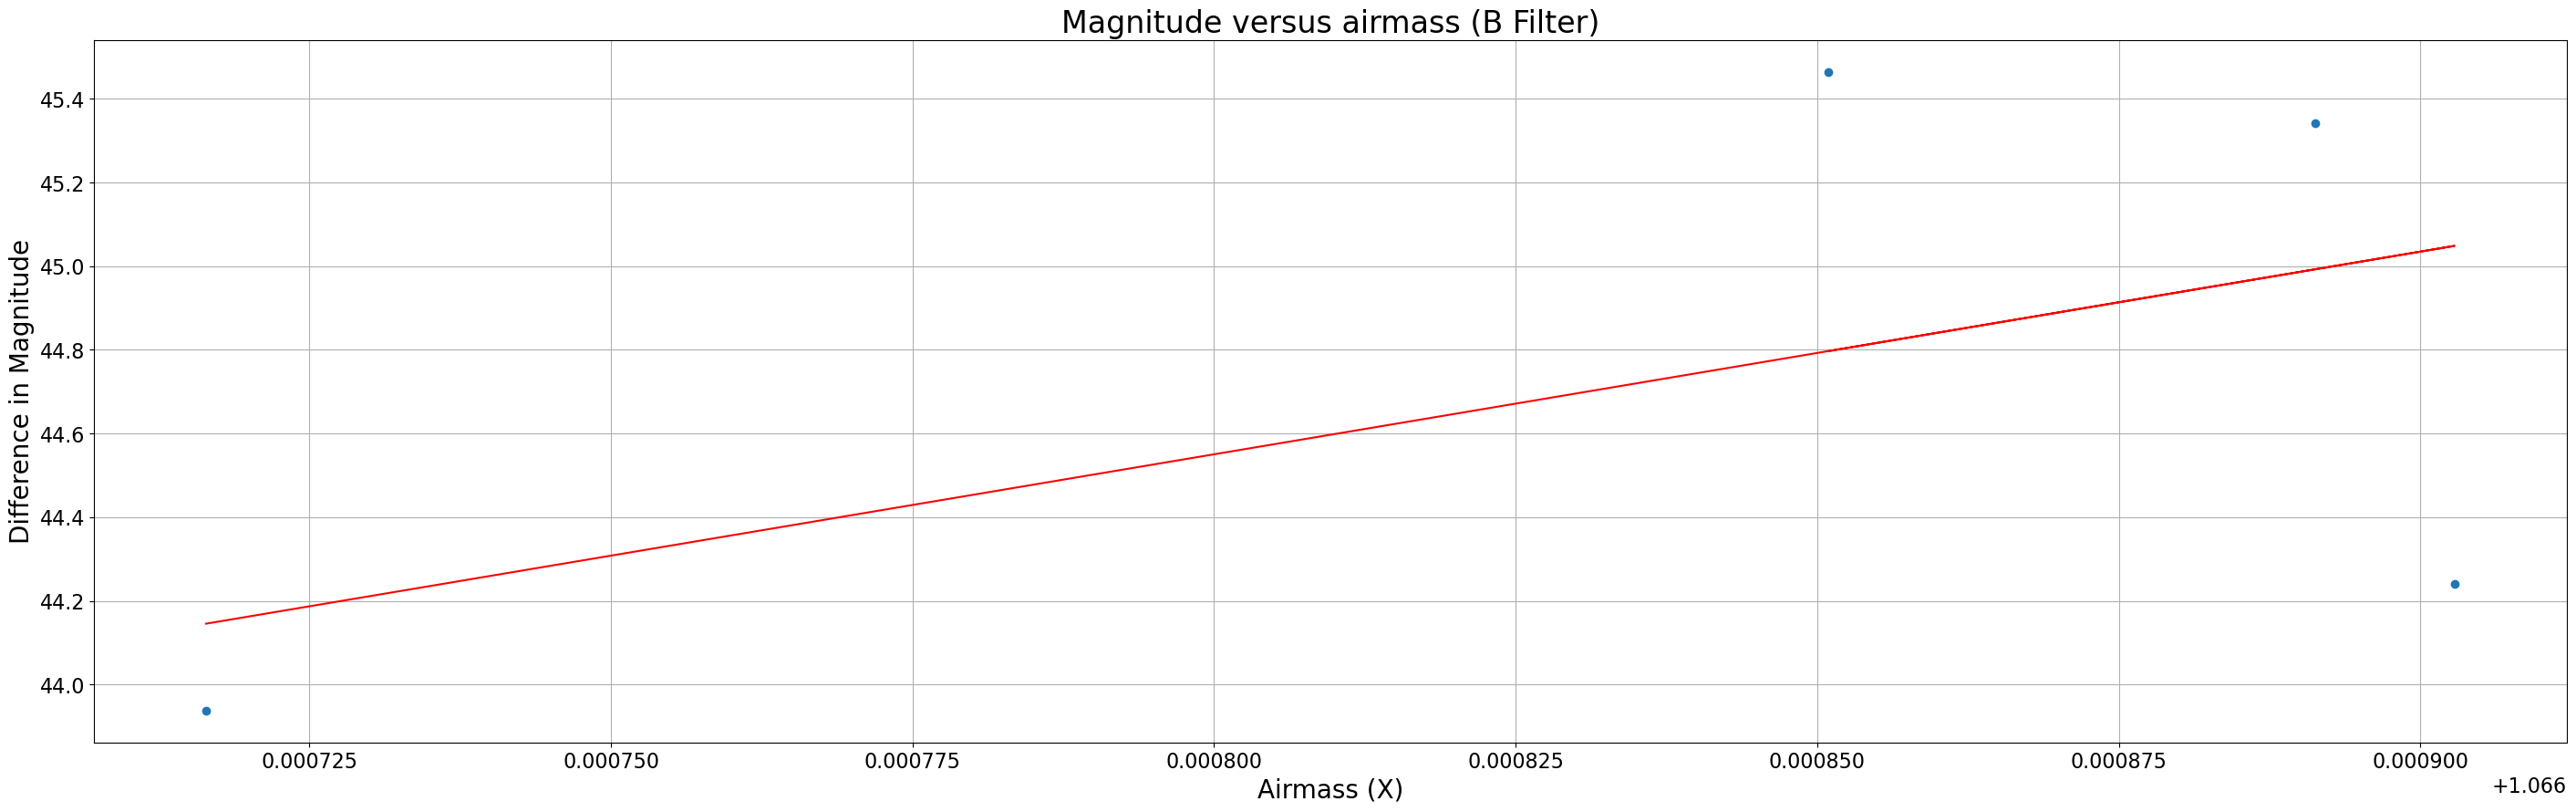

In [541]:
plt.figure(figsize=(35, 10))
y_b=np.array([43.93779325613437, 45.34119251595091, 44.2398099964733, 45.46455029427575])
plt.scatter(airmass, mags_b)
m_b, b = np.polyfit(x, y_b, 1)
plt.plot(x, m_b*x + b, color='red') # Plot the fit line
plt.xlabel(r'Airmass (X)')
plt.ylabel('Difference in Magnitude')
plt.title('Magnitude versus airmass (B Filter)')
plt.show()

In [542]:
m_b

4844.807502005131

### U filter

In [535]:
ins_mags_u_b=np.array([-19.078498604157044,-20.943261063764268,-19.717115248857105,-23.295247340824442])

In [538]:
u_b=np.array([0.320, 1.007, 1.138, -0.025])
mags_u=[]
um=[]
for i,b,c in zip(ins_mags_u_b, bm, u_b):
    u=c+b
    um.append(u)
    m = u-i
    mags_u.append(m)

In [539]:
mags_u

[35.527498604157046, 36.00026106376427, 35.2181152488571, 37.49624734082444]

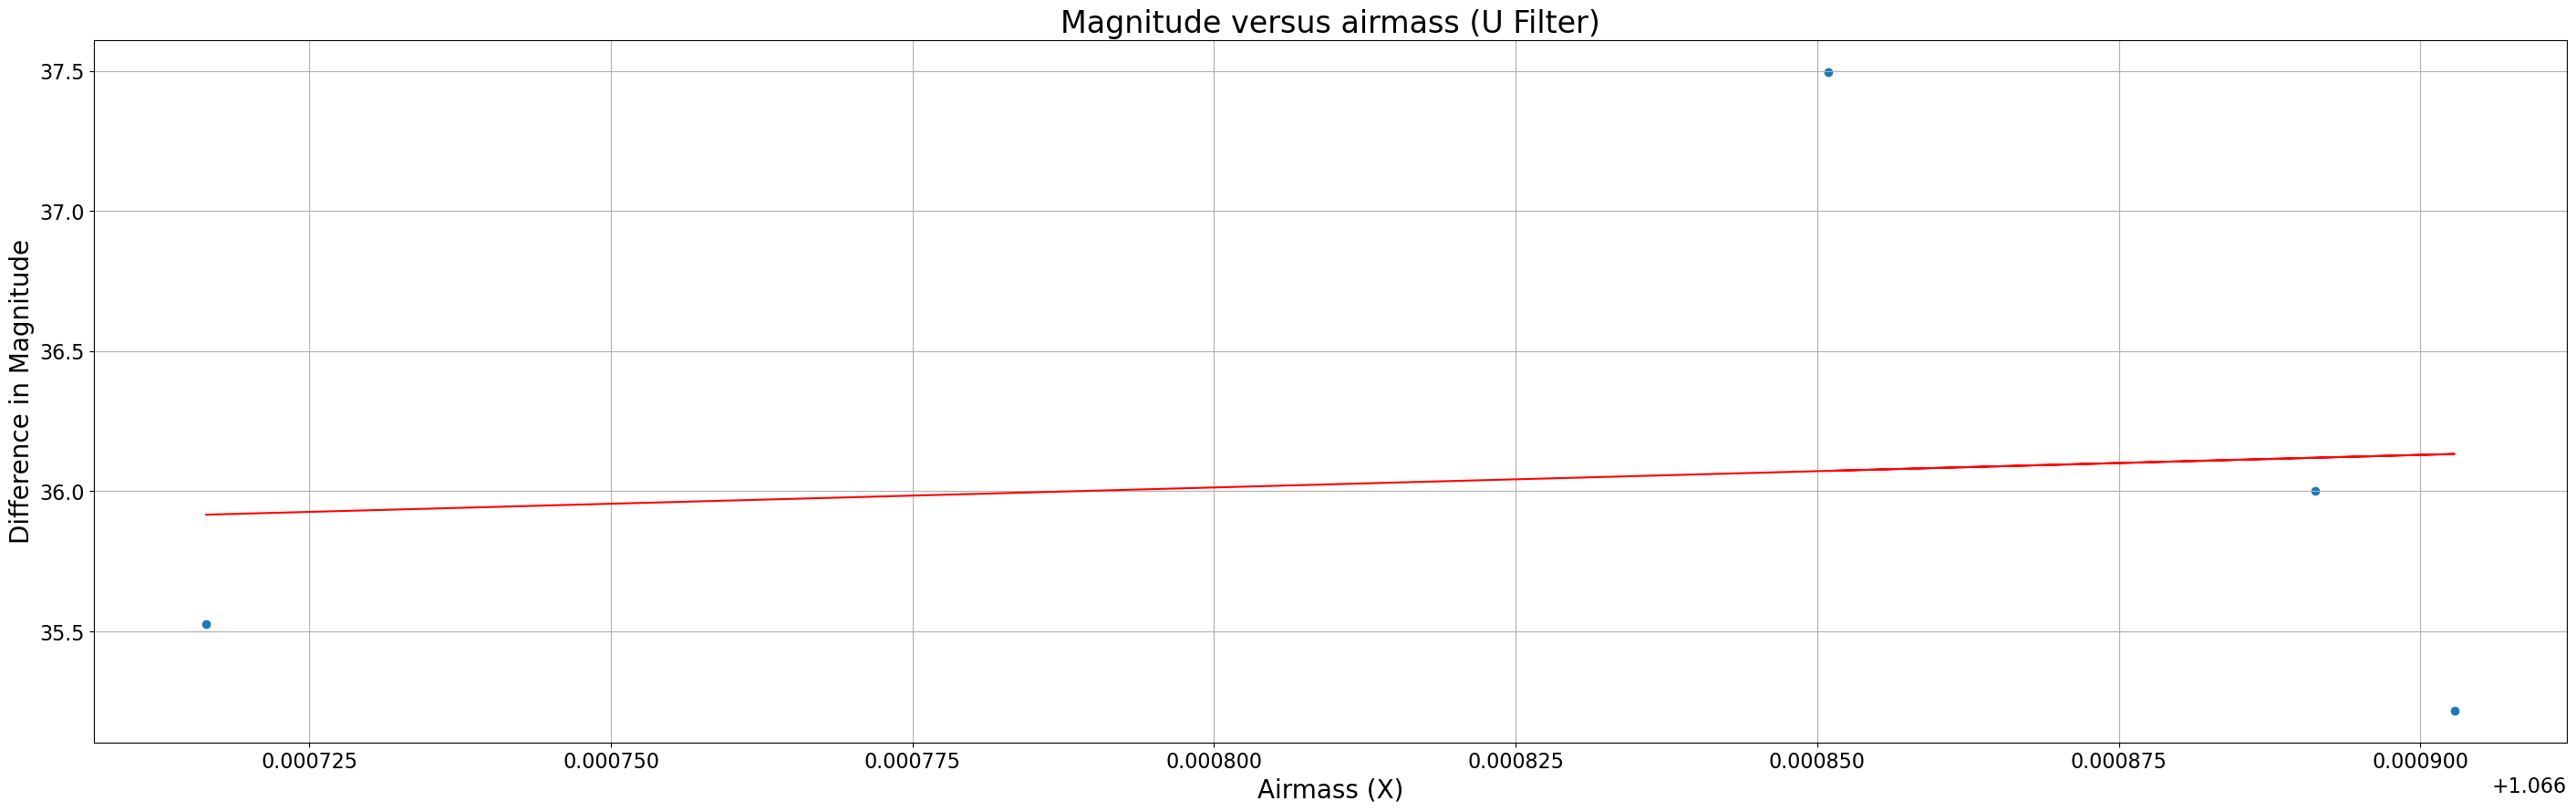

In [543]:
plt.figure(figsize=(35, 10))
y_u=np.array([35.527498604157046, 36.00026106376427, 35.2181152488571, 37.49624734082444])
plt.scatter(airmass, mags_u)
m_u, b = np.polyfit(x, y_u, 1)
plt.plot(x, m_u*x + b, color='red') # Plot the fit line
plt.xlabel(r'Airmass (X)')
plt.ylabel('Difference in Magnitude')
plt.title('Magnitude versus airmass (U Filter)')
plt.show()

In [544]:
m_u

1161.5066287322313

### R filter

In [548]:
ins_mags_v_r=np.array([-28.427816404790185, -32.877138108991176, -31.65910360677841, -30.928536887297263])

In [560]:
v_r=np.array([0.505, 0.590, 0.618, 0.324])
mags_r=[]
rm=[]
for i,v,c in zip(ins_mags_v_r, lan_mags, v_r):
    r=v-c
    rm.append(r)
    m = r-i
    mags_r.append(m)

In [561]:
mags_r

[43.17881640479018, 45.25613810899117, 44.270103606778406, 44.29553688729726]

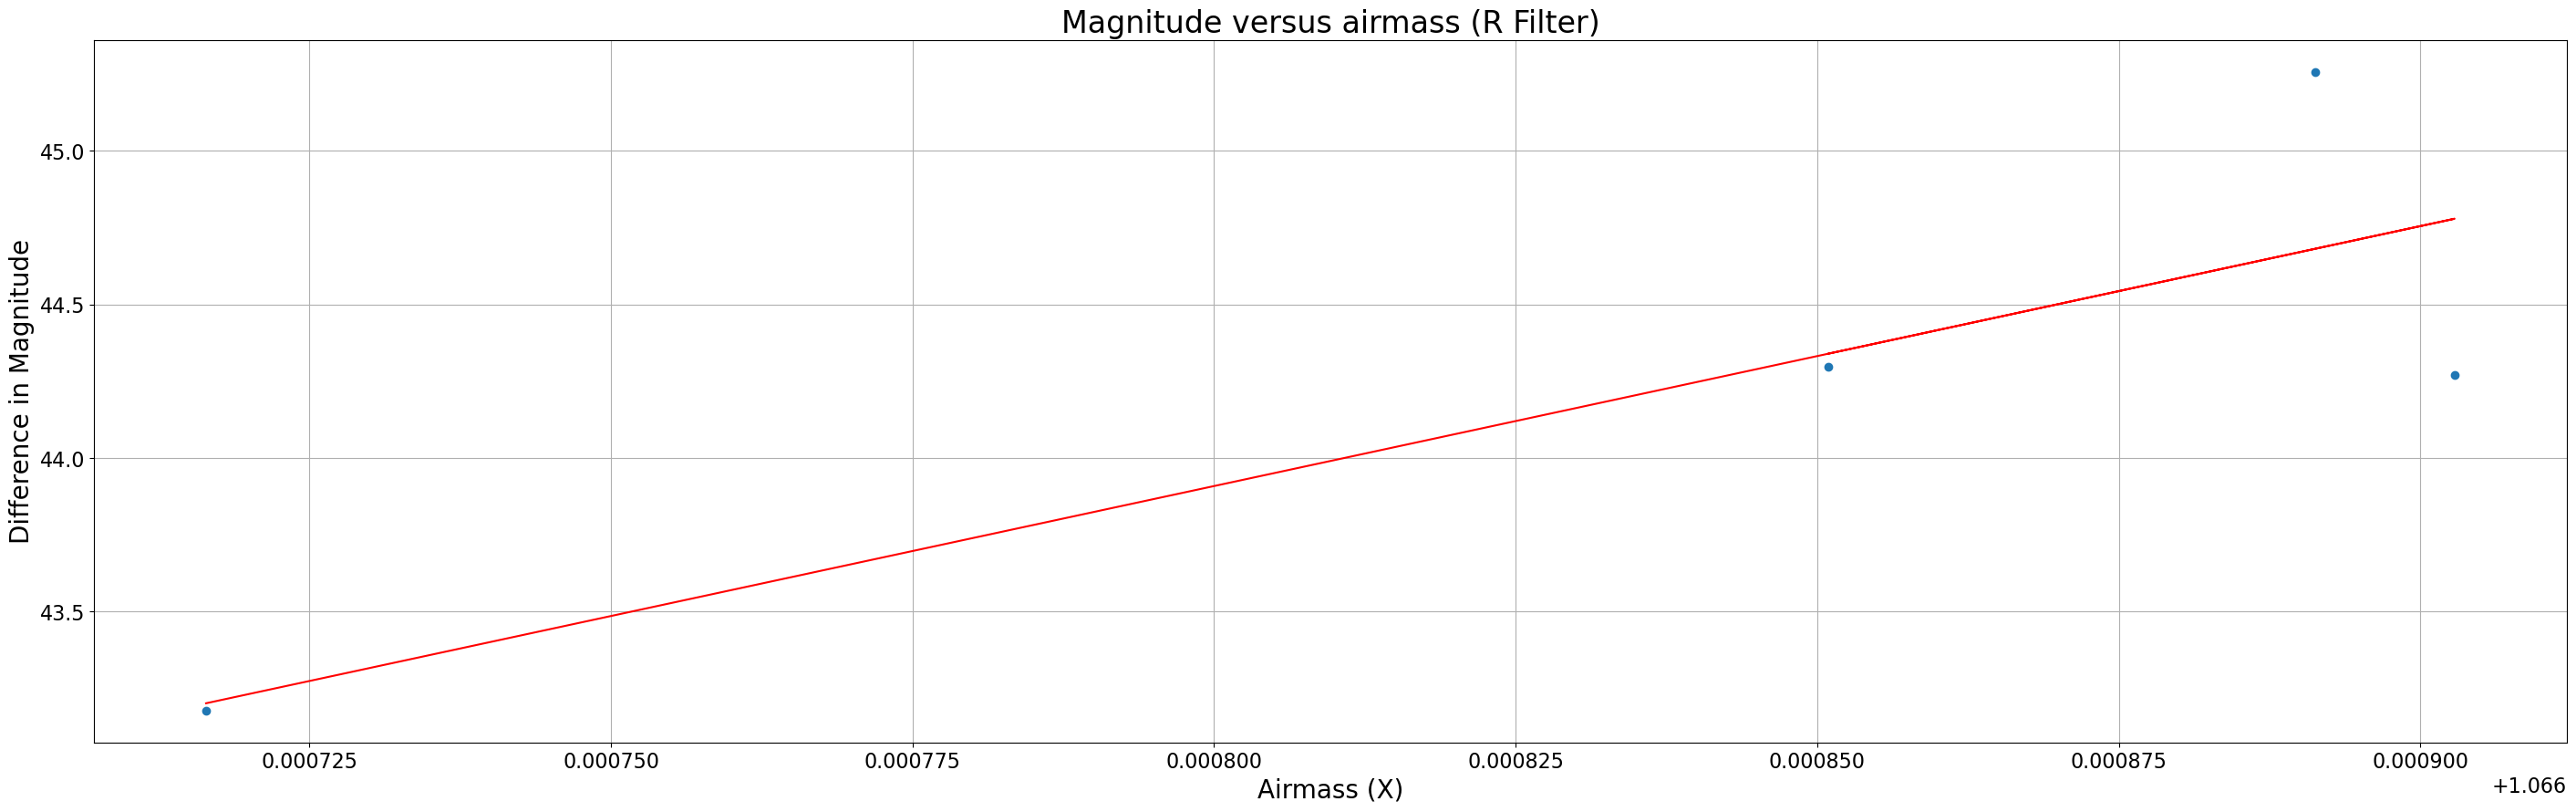

In [562]:
plt.figure(figsize=(35, 10))
y_r=np.array([43.17881640479018, 45.25613810899117, 44.270103606778406, 44.29553688729726])
plt.scatter(airmass, mags_r)
m_r, b = np.polyfit(x, y_r, 1)
plt.plot(x, m_r*x + b, color='red') # Plot the fit line
plt.xlabel(r'Airmass (X)')
plt.ylabel('Difference in Magnitude')
plt.title('Magnitude versus airmass (R Filter)')
plt.show()

In [563]:
m_r

8454.112662284686

### I filter

In [565]:
ins_mags_r_i=np.array([-27.539170716983648, -31.478606988904442, -29.556608949910412, -28.52317114289142])

In [568]:
r_i=np.array([0.511, 0.502, 0.523, 0.327])
mags_i=[]
im=[]
for i,r,c in zip(ins_mags_r_i, rm, r_i):
    i_fil=r-c
    im.append(i_fil)
    m = i_fil-i
    mags_i.append(m)

In [569]:
mags_i

[41.77917071698365, 43.35560698890444, 41.64460894991041, 41.56317114289142]

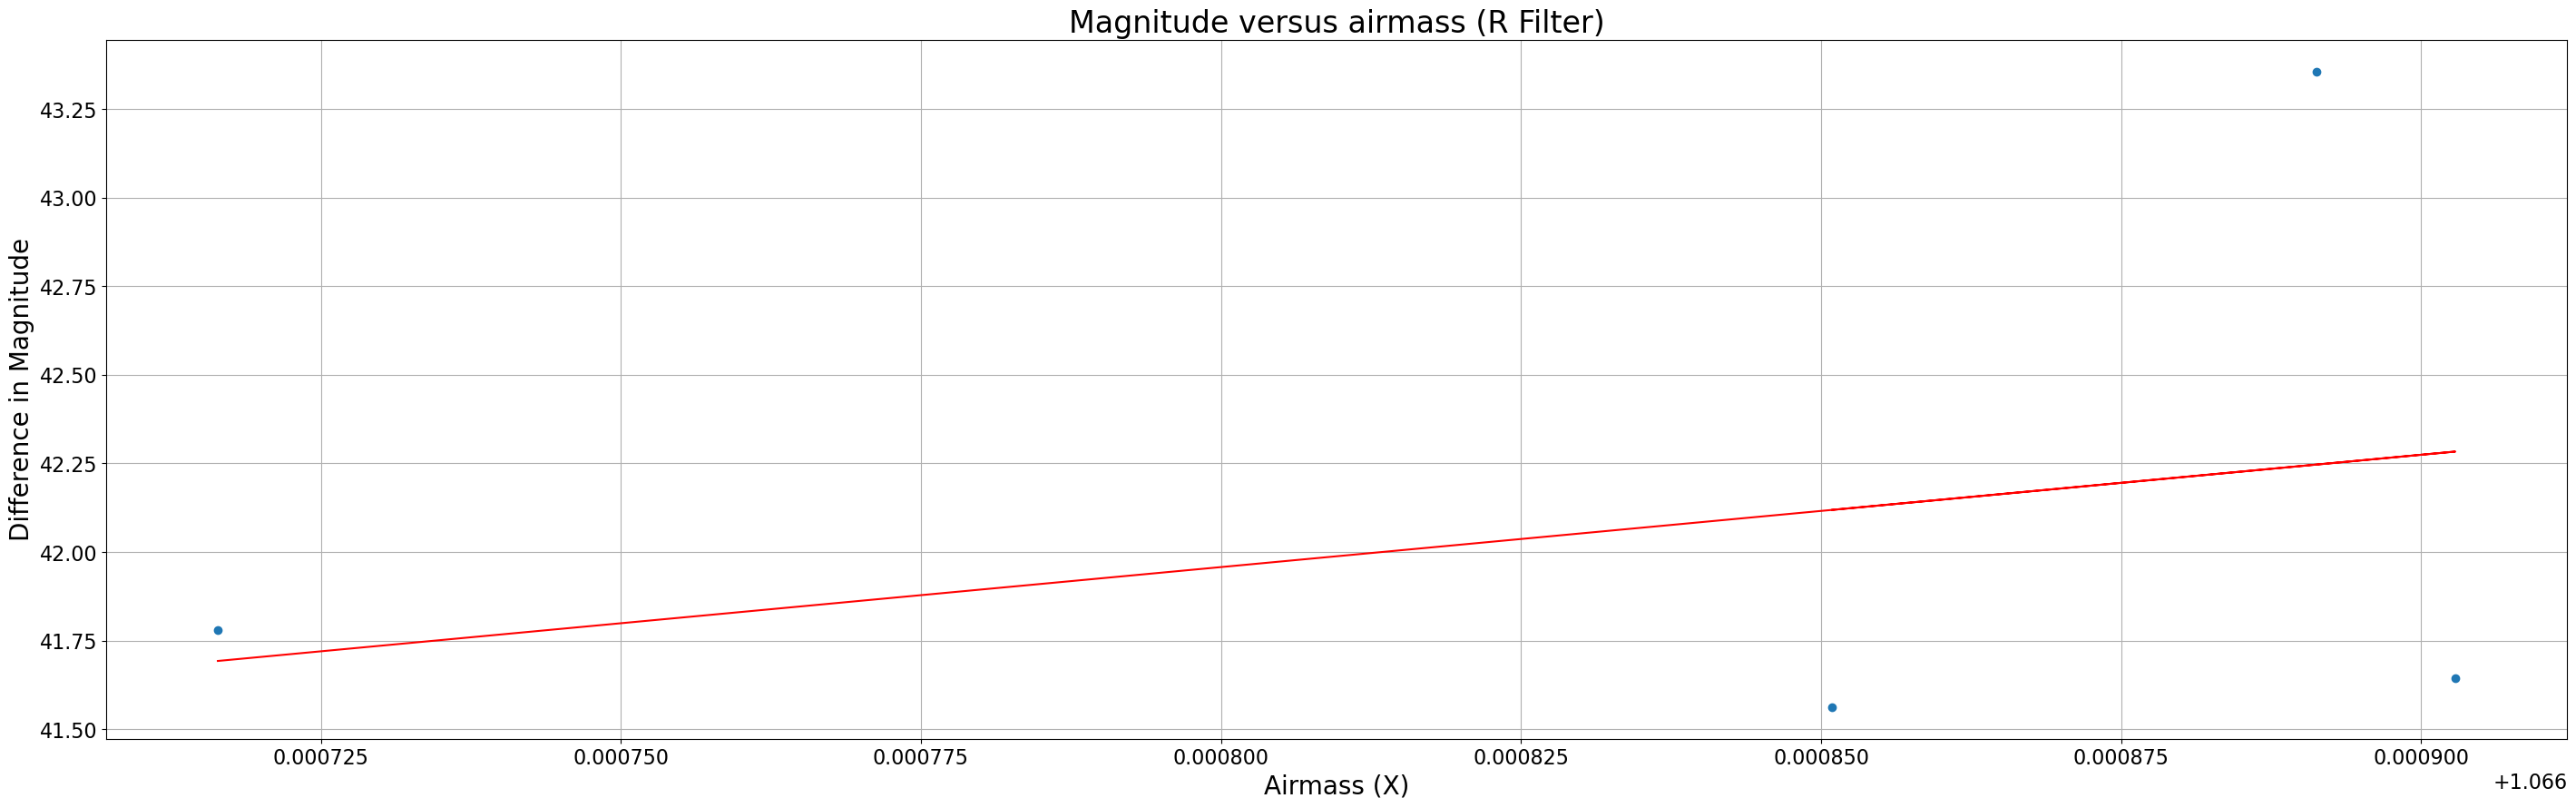

In [570]:
plt.figure(figsize=(35, 10))
y_i=np.array([41.77917071698365, 43.35560698890444, 41.64460894991041, 41.56317114289142])
plt.scatter(airmass, mags_i)
m_i, b = np.polyfit(x, y_i, 1)
plt.plot(x, m_i*x + b, color='red') # Plot the fit line
plt.xlabel(r'Airmass (X)')
plt.ylabel('Difference in Magnitude')
plt.title('Magnitude versus airmass (R Filter)')
plt.show()

In [571]:
m_i

3167.8477969539435

In [572]:
v_i=np.array([1.015, 1.090, 1.138, 0.650])
mags_i_2=[]
im_2=[]
for i,v,c in zip(ins_mags_r_i, lan_mags, v_i):
    i_fil=v-c
    im_2.append(i_fil)
    m = i_fil-i
    mags_i_2.append(m)

In [573]:
mags_i_2

[41.78017071698365, 43.35760698890444, 41.64760894991041, 41.564171142891425]

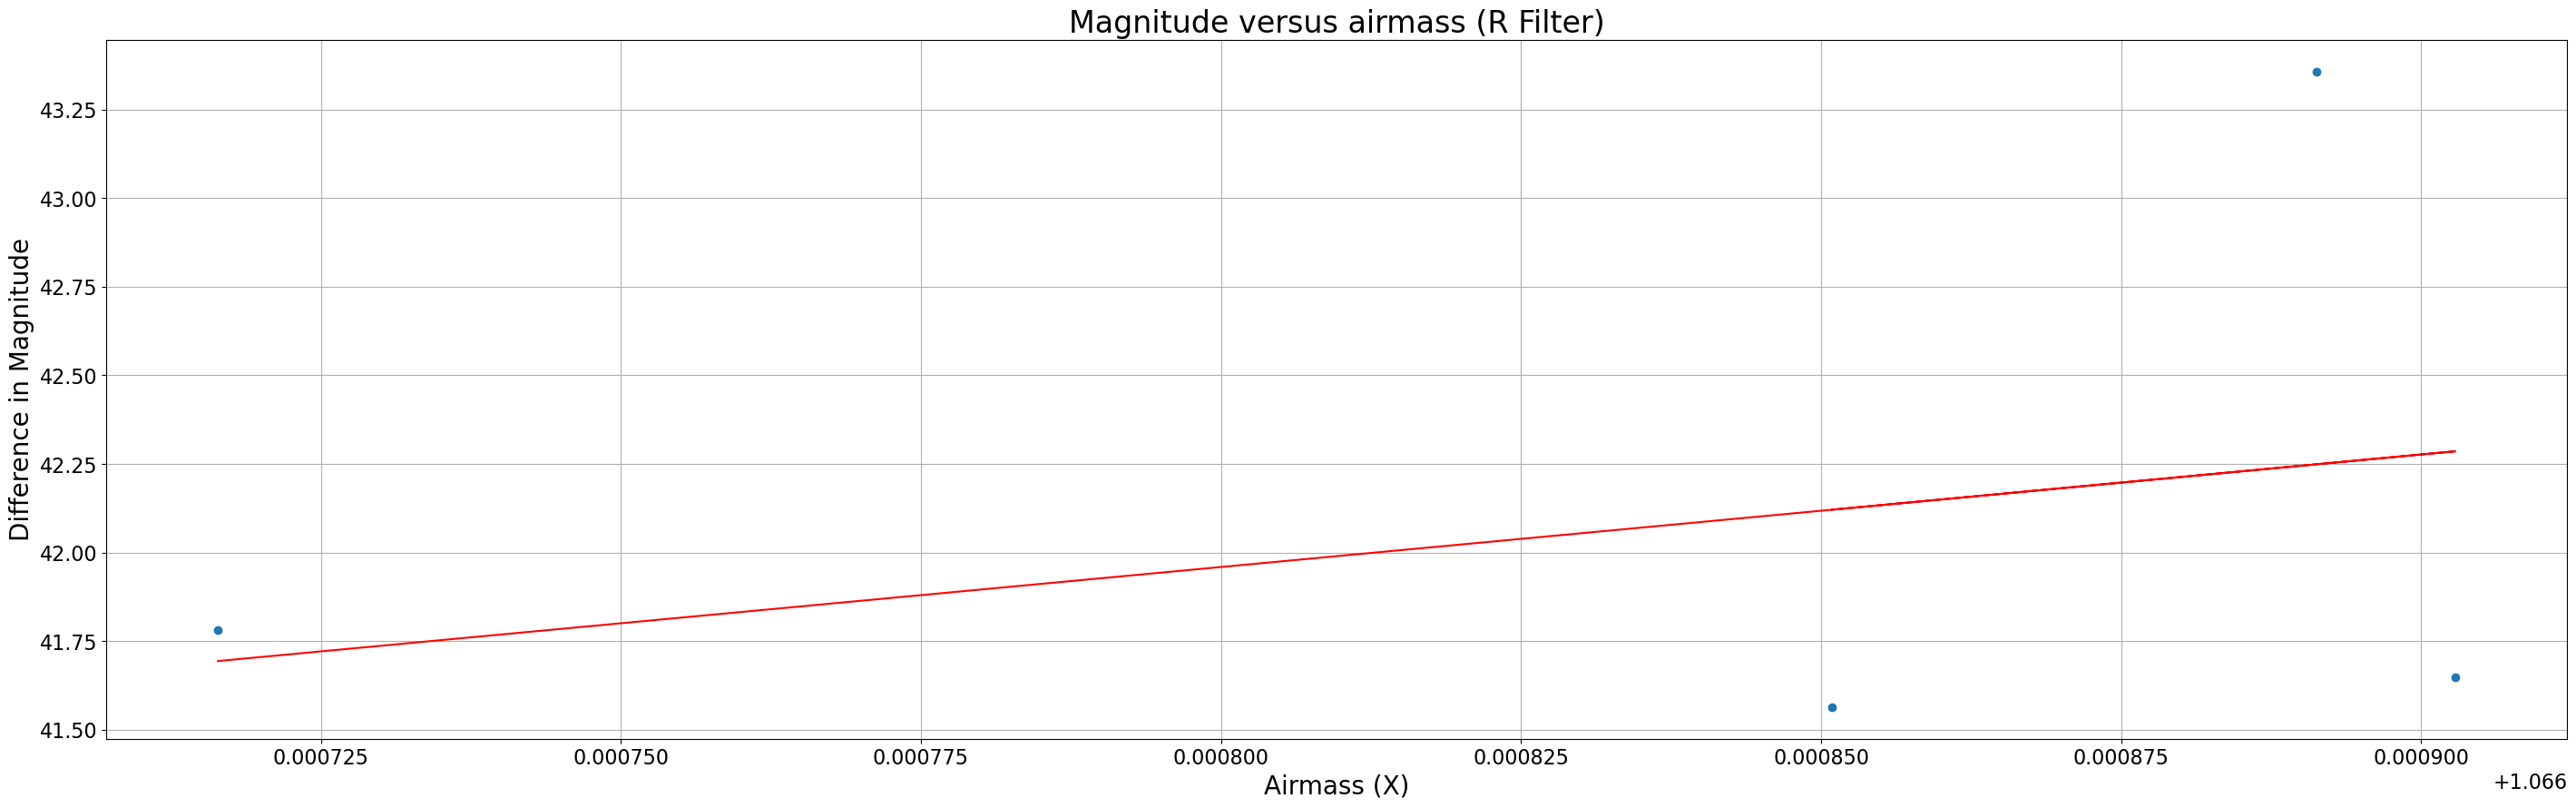

In [574]:
plt.figure(figsize=(35, 10))
y_i_2=np.array([41.78017071698365, 43.35760698890444, 41.64760894991041, 41.564171142891425])
plt.scatter(airmass, mags_i_2)
m_i_2, b = np.polyfit(x, y_i_2, 1)
plt.plot(x, m_i_2*x + b, color='red') # Plot the fit line
plt.xlabel(r'Airmass (X)')
plt.ylabel('Difference in Magnitude')
plt.title('Magnitude versus airmass (R Filter)')
plt.show()

In [575]:
m_i_2

3175.852154773301

*I know that the extinction coefficient is supposed to be the slope, but all the values I found are way higher than what the k is supposed to be. Something likely went wrong with my equations/axes. -HH

## 6. After extinction correcting your standard stars to zero airmasses (i.e., you’re correcting to the top of the atmosphere), make a plot of the diﬀerence between real magnitudes and instrumental magnitudes using your standard stars as a function of V−R color and B−V color. 
Fit a linear relation to this trend. The fit gives you your instrumental zero points and the first order color term which let you transform your instrumental photometry to the standard system. Tabulate the instrumental zero point and first order color terms for each band in a neat, digestible way.

*Slope is color term (c) and intercept is zero point (ZP) -HH

In [820]:
inst_magv=np.concatenate((ins_mag_074, ins_mag_085,ins_mag_134,ins_mag_206,ins_mag_241))
inst_magv

array([-21.16447134, -27.93335888, -27.23551183, -26.31737296,
       -28.8278741 , -32.82163865, -31.38232618, -31.58117243,
       -27.30369946, -32.68862463, -31.12719895, -30.97722556,
       -27.45038568, -32.64484373, -32.0563956 , -31.04544422,
       -27.30369946, -32.68862463, -31.12719895, -30.97722556])

In [830]:
def v_ec(minst, am, lm):
    m=minst-(1.5475683035228747*am)
    diff_m=lm-m
    return diff_m

In [832]:
v_ec(inst_magv, airmassv, land_mags*5)

array([38.26207762, 42.74396516, 42.30611811, 41.84997924, 45.98738312,
       47.69414767, 46.51483519, 47.17568145, 44.47868416, 47.57660933,
       46.27518365, 46.58721026, 45.01226246, 47.91972051, 47.59127237,
       47.042321  , 44.86557623, 47.96350141, 46.66207572, 46.97410234])

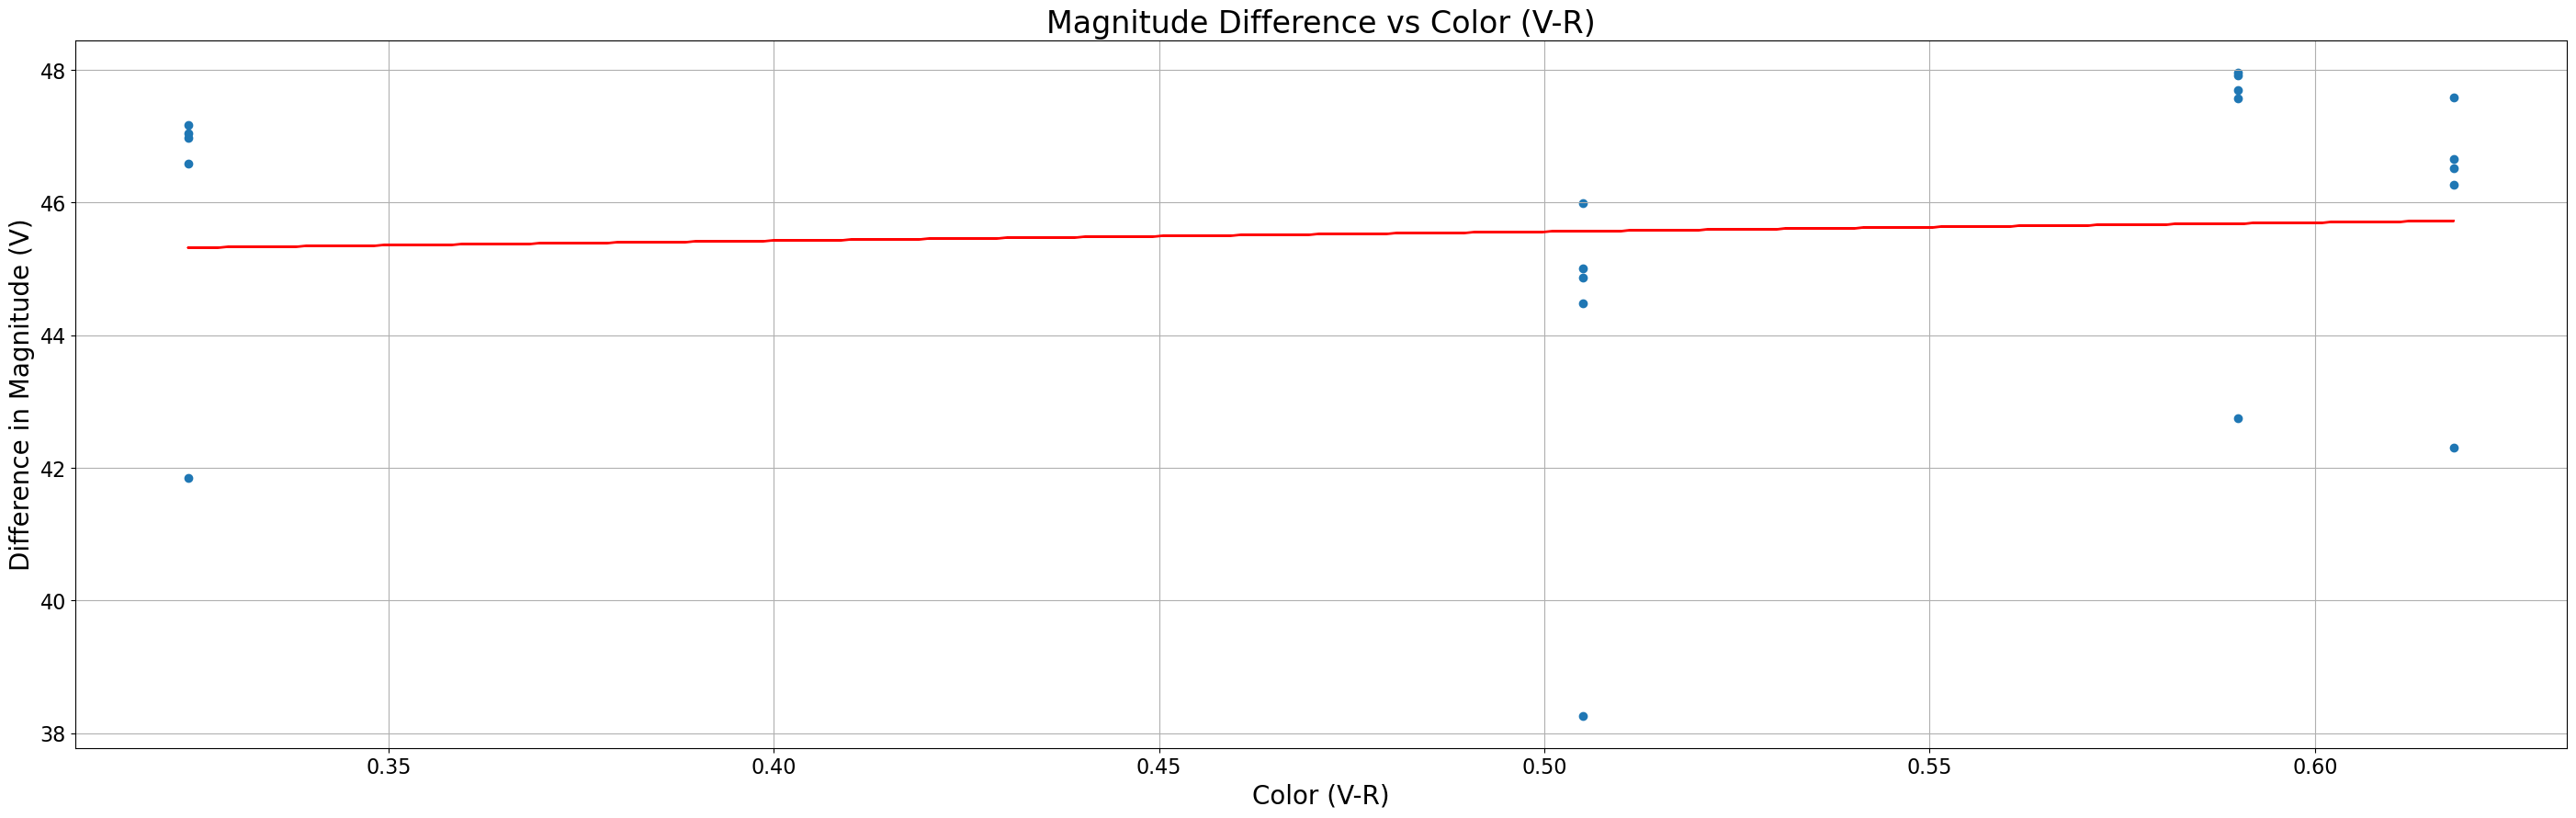

In [886]:
plt.figure(figsize=(35, 10))
v_r5=np.array([0.505, 0.590, 0.618, 0.324]*5)
#y_v_r=np.array([43.17881640479018, 45.25613810899117, 44.270103606778406, 44.29553688729726])
plt.scatter(v_r5, v_ec(inst_magv, airmassv, land_mags*5))
m_vrc, brc = np.polyfit(v_r5, v_ec(inst_magv, airmassv, land_mags*5), 1)
plt.plot(v_r5, m_vrc*v_r5 + brc, color='red') # Plot the fit line
plt.xlabel(r'Color (V-R)')
plt.ylabel('Difference in Magnitude (V)')
plt.title('Magnitude Difference vs Color (V-R)')
plt.show()

In [837]:
m_vrc, brc

(1.370897631482079, 44.876005730084515)

In [838]:
inst_magb=np.concatenate((ins_mag_083, ins_mag_132,ins_mag_133,ins_mag_204,ins_mag_239))
inst_magb

array([-27.80879326, -31.29119252, -29.87681   , -31.23855029,
       -27.94565417, -32.73698129, -32.0307842 , -32.25293968,
       -28.03510482, -32.69491457, -31.99285773, -32.2207959 ,
       -24.32517905, -28.76467045, -26.01797585, -26.1060639 ,
       -27.32657814, -32.22603253, -31.53778811, -31.76911429])

In [867]:
b_v2=np.array([0.873, 1.081, 1.134, 0.535, 0.873, 1.081, 1.134, 0.535, 0.873, 1.081, 1.134, 0.535, 0.873, 1.081, 1.134, 0.535, 0.873, 1.081, 1.134, 0.535])
def b_ec(minst, am, lm, bv):
    m=minst-(0.3578707980089391*am)
    b=bv+lm
    diff_m=b-m
    return diff_m

In [868]:
b_ec(inst_magb, airmassb, land_mags*5, b_v2)

array([44.3600808 , 45.76348006, 44.66209754, 45.88683784, 44.51841396,
       47.23074108, 46.83754399, 46.92269947, 44.70448973, 47.28529947,
       46.89624264, 46.98718081, 40.99456395, 43.35505535, 40.92136075,
       40.87244881, 44.49340345, 47.31385784, 46.93861343, 47.03293961])

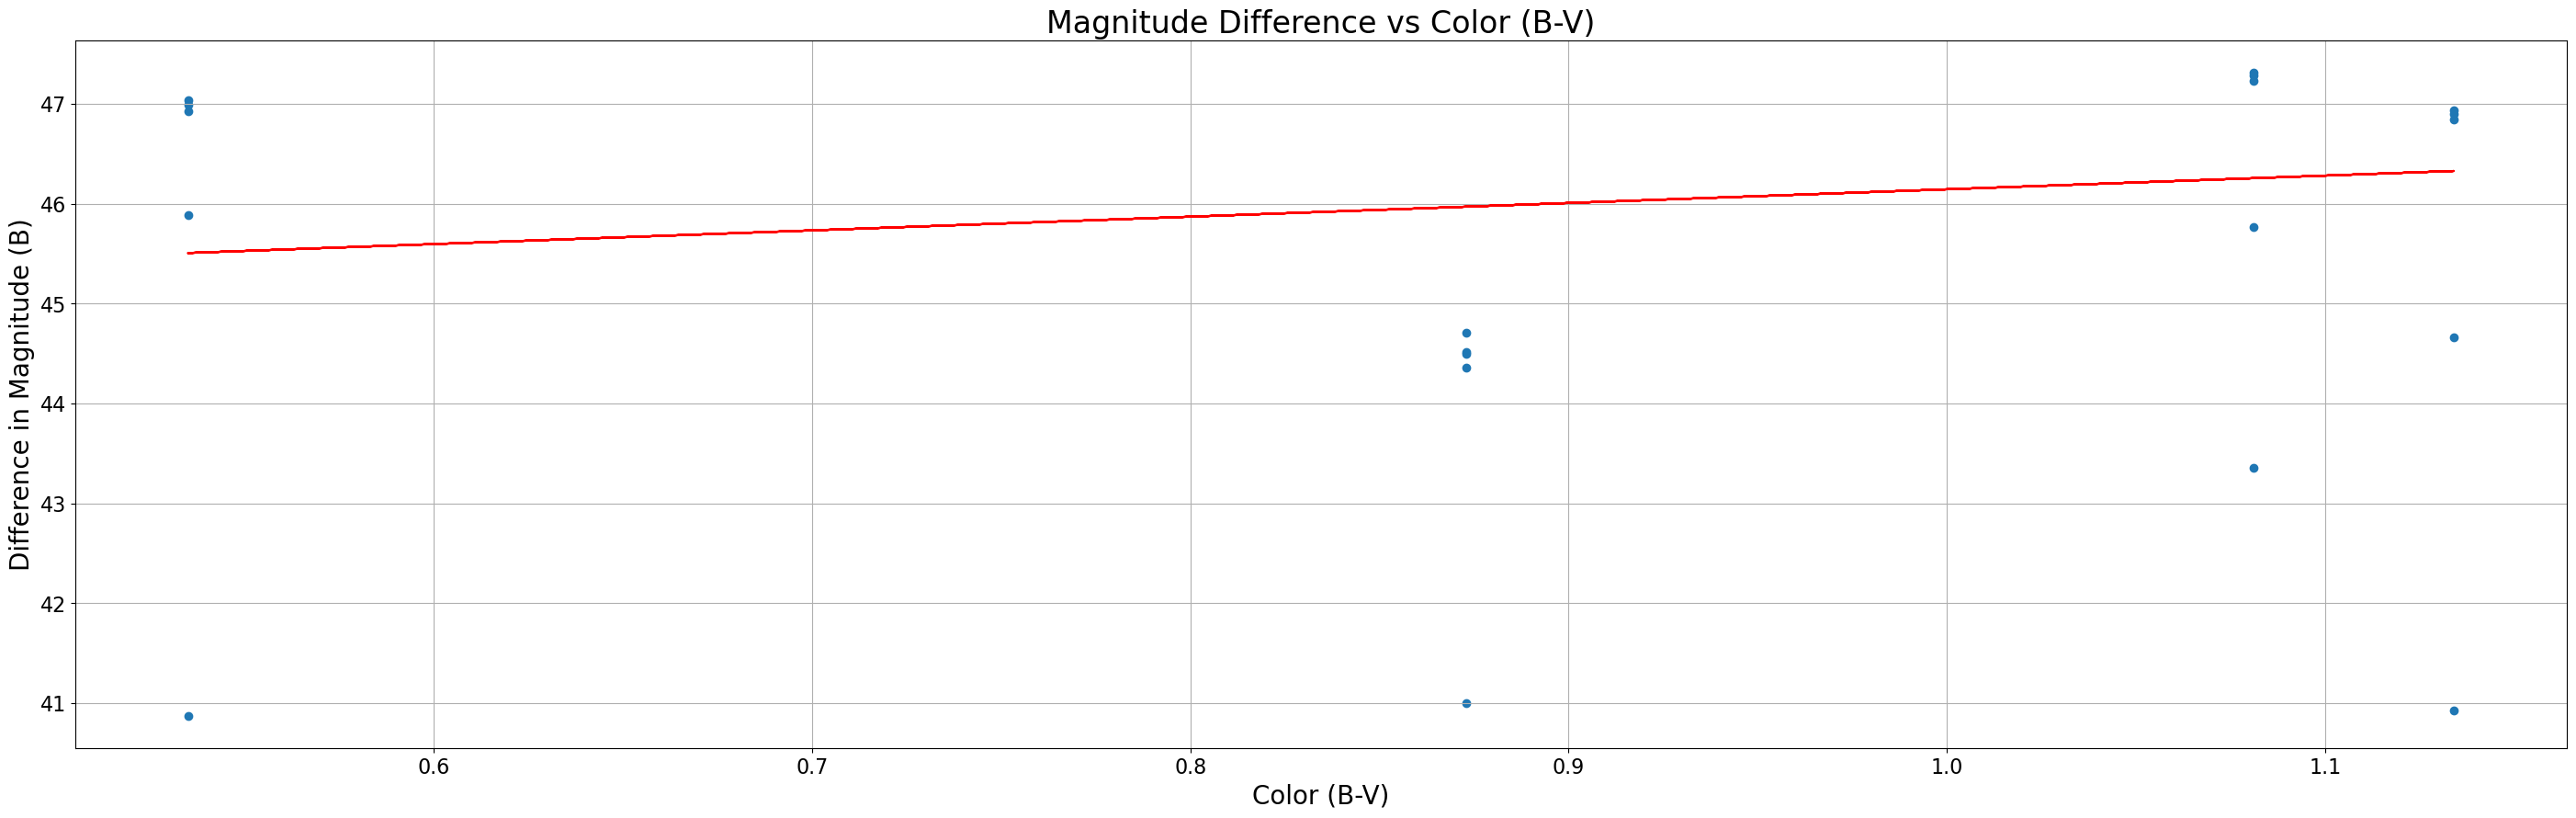

In [885]:
plt.figure(figsize=(35, 10))
#b_v5=np.array([0.505, 0.590, 0.618, 0.324]*5)
#y_v_r=np.array([43.17881640479018, 45.25613810899117, 44.270103606778406, 44.29553688729726])
plt.scatter(b_v2, b_ec(inst_magb, airmassb, land_mags*5, b_v2))
m_brc, bbrc = np.polyfit(b_v2, b_ec(inst_magb, airmassb, land_mags*5, b_v2), 1)
plt.plot(b_v2, m_vrc*b_v2 + bbrc, color='red') # Plot the fit line
plt.xlabel(r'Color (B-V)')
plt.ylabel('Difference in Magnitude (B)')
plt.title('Magnitude Difference vs Color (B-V)')
plt.show()

In [870]:
m_brc, bbrc

(0.47120806730328413, 44.77207082135167)

In [876]:
inst_magr=np.concatenate((ins_mag_087, ins_mag_136,ins_mag_208,ins_mag_243,ins_mag_244))
inst_magr

array([-28.4278164 , -32.87713811, -31.65910361, -30.92853689,
       -28.72030505, -34.19325769, -33.64818671, -31.98534993,
       -23.64522401, -26.90042401, -25.39079276, -25.98017225,
       -24.32517905, -28.76467045, -26.01797585, -26.1060639 ,
       -28.19416287, -33.17643045, -32.45853218, -31.30421861])

In [877]:
v_r2=np.array([0.505, 0.590, 0.618, 0.324, 0.505, 0.590, 0.618, 0.324, 0.505, 0.590, 0.618, 0.324, 0.505, 0.590, 0.618, 0.324, 0.505, 0.590, 0.618, 0.324])
def r_ec(minst, am, lm, vr):
    m=minst-(-1.9309813293201123*am)
    r=lm-vr
    diff_m=r-m
    return diff_m

In [878]:
r_ec(inst_magr, airmassr, land_mags*5, v_r2)

array([40.90025844, 42.97758014, 41.99154564, 42.01697892, 41.0768882 ,
       44.17784084, 43.86476986, 42.95793308, 35.44182258, 36.32502257,
       35.04739133, 36.39277082, 34.77009068, 36.83758208, 34.32288748,
       35.16697554, 38.63907451, 41.24934208, 40.76344381, 40.36513024])

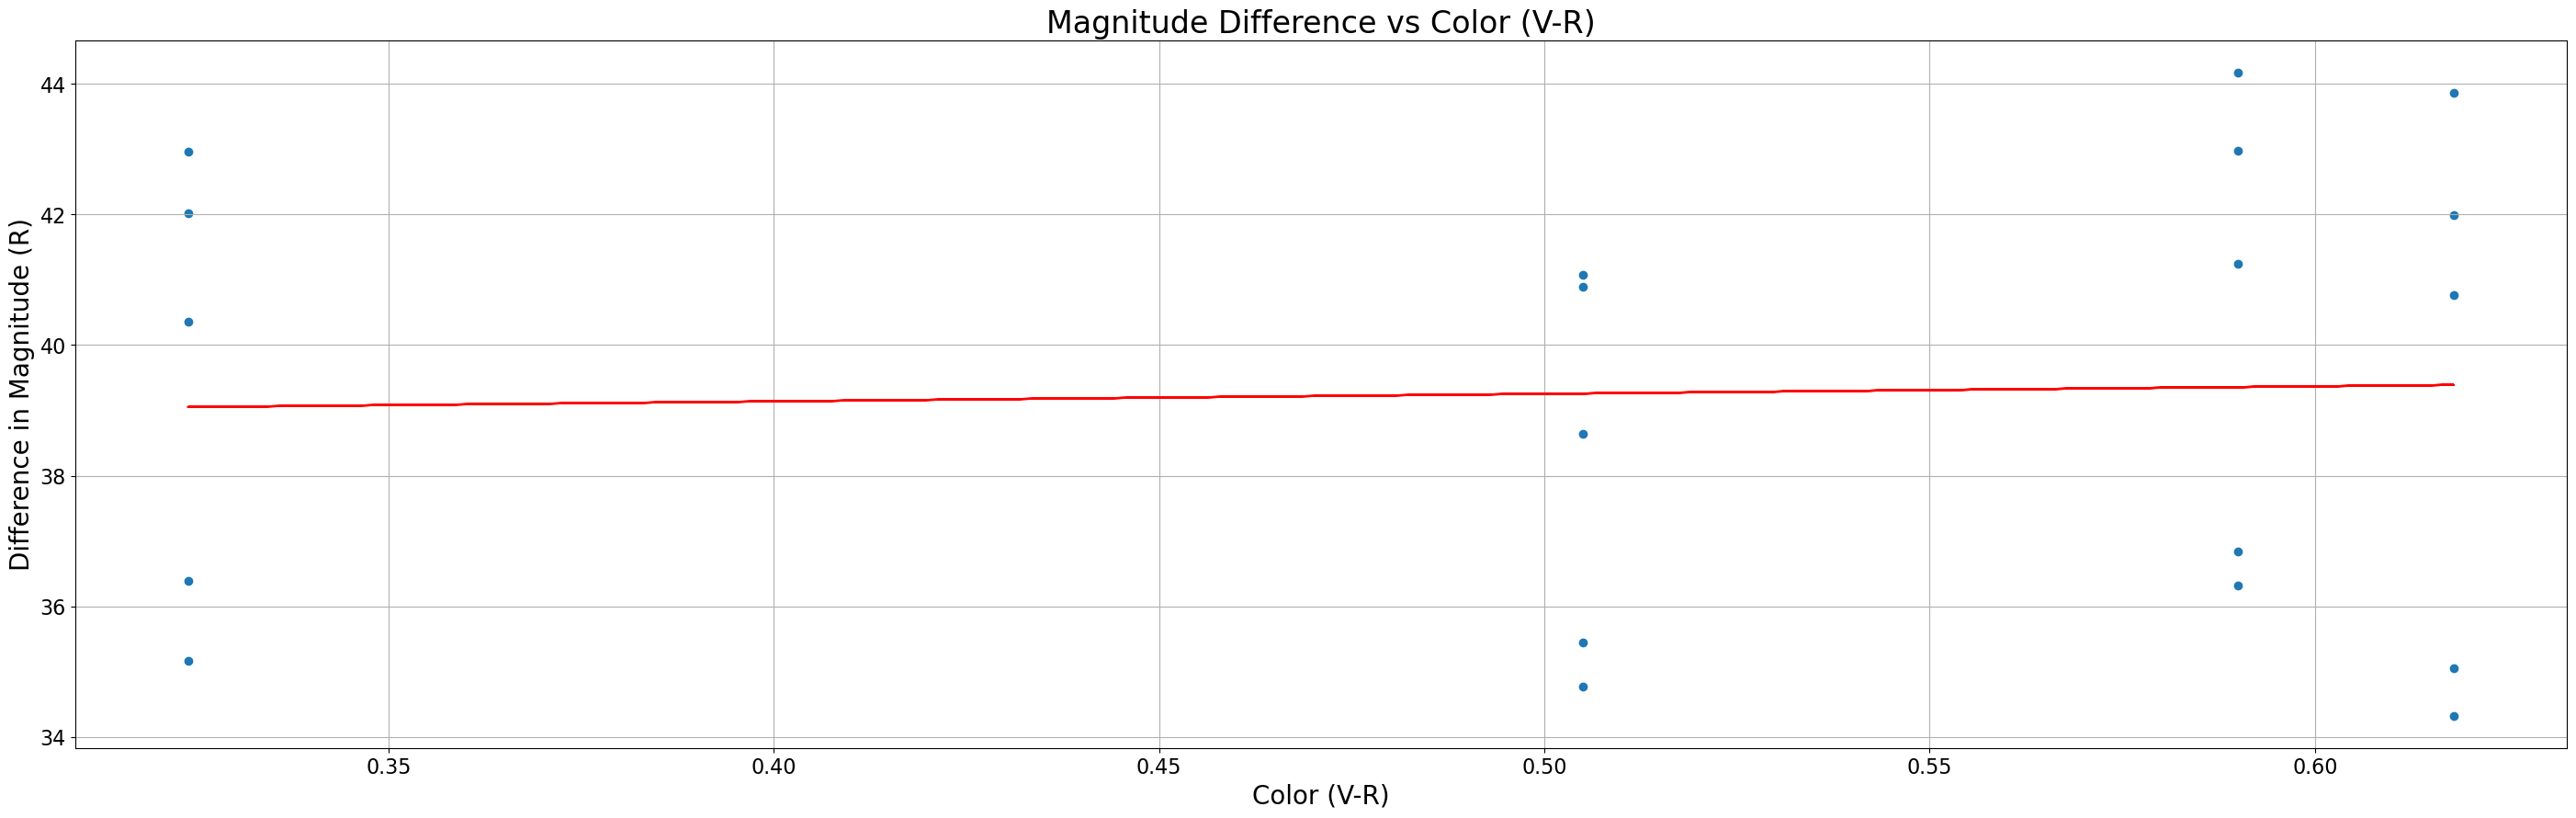

In [884]:
plt.figure(figsize=(35, 10))
#b_v5=np.array([0.505, 0.590, 0.618, 0.324]*5)
#y_v_r=np.array([43.17881640479018, 45.25613810899117, 44.270103606778406, 44.29553688729726])
plt.scatter(v_r2, r_ec(inst_magr, airmassr, land_mags*5, v_r2))
m_rrc, brrc = np.polyfit(v_r2, r_ec(inst_magr, airmassr, land_mags*5, v_r2), 1)
plt.plot(v_r2, m_rrc*v_r2 + brrc, color='red') # Plot the fit line
plt.xlabel(r'Color (V-R)')
plt.ylabel('Difference in Magnitude (R)')
plt.title('Magnitude Difference vs Color (V-R)')
plt.show()

In [882]:
m_rrc, brrc

(1.1532282596036179, 38.67698495173373)

In [887]:
inst_magv=np.concatenate((ins_mag_074, ins_mag_085,ins_mag_134,ins_mag_206,ins_mag_241))
inst_magv

array([-21.16447134, -27.93335888, -27.23551183, -26.31737296,
       -28.8278741 , -32.82163865, -31.38232618, -31.58117243,
       -27.30369946, -32.68862463, -31.12719895, -30.97722556,
       -27.45038568, -32.64484373, -32.0563956 , -31.04544422,
       -27.30369946, -32.68862463, -31.12719895, -30.97722556])

In [888]:
def v_ec(minst, am, lm):
    m=minst-(1.5475683035228747*am)
    diff_m=lm-m
    return diff_m

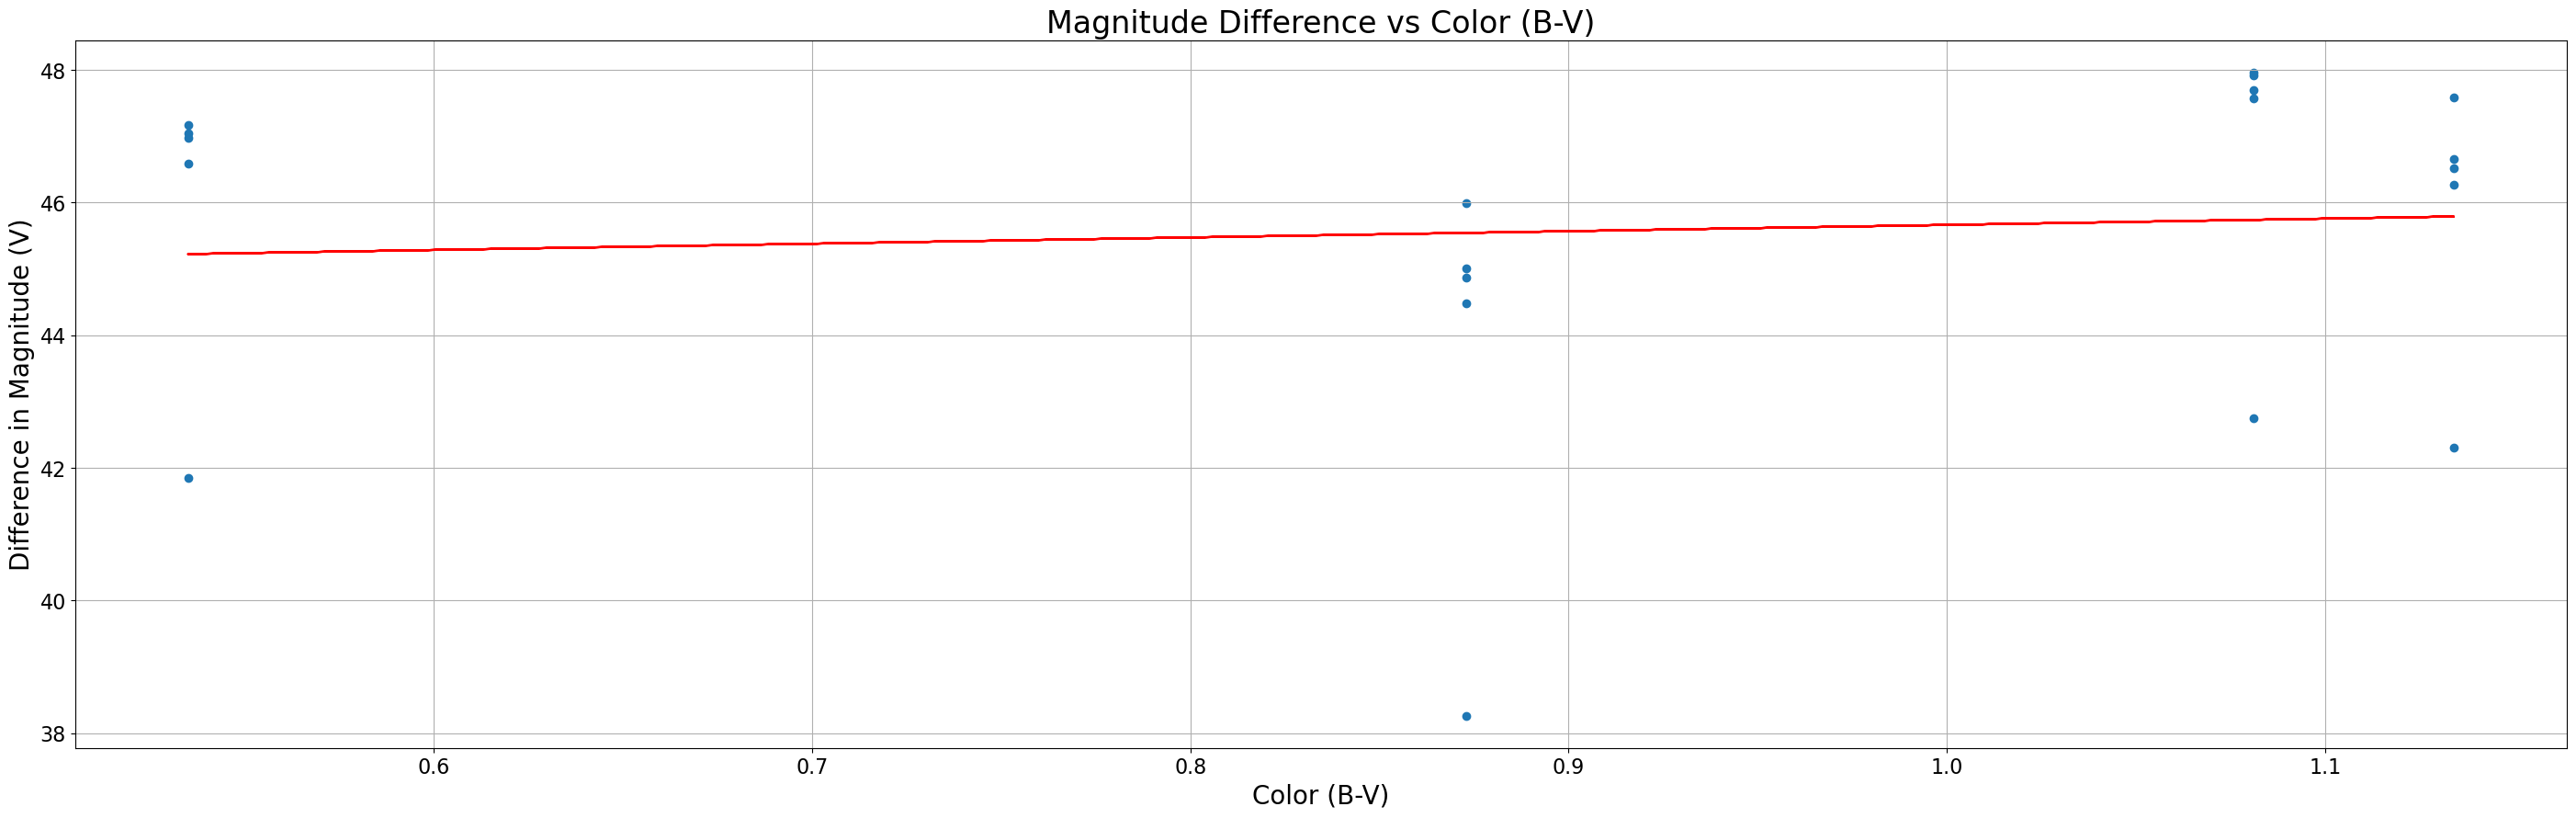

In [889]:
plt.figure(figsize=(35, 10))
#b_v5=np.array([0.505, 0.590, 0.618, 0.324]*5)
#y_v_r=np.array([43.17881640479018, 45.25613810899117, 44.270103606778406, 44.29553688729726])
plt.scatter(b_v2, v_ec(inst_magv, airmassv, land_mags*5))
m_bvrc, bvrc = np.polyfit(b_v2, v_ec(inst_magv, airmassv, land_mags*5), 1)
plt.plot(b_v2, m_bvrc*b_v2 + bvrc, color='red') # Plot the fit line
plt.xlabel(r'Color (B-V)')
plt.ylabel('Difference in Magnitude (V)')
plt.title('Magnitude Difference vs Color (B-V)')
plt.show()

In [890]:
m_bvrc, bvrc

(0.9444598757335012, 44.718690816471145)

In [894]:
import pandas as pd
df = pd.DataFrame(
    [['V', '(V-R)', 1.370897631482079, 44.876005730084515], ['B', '(B-V)', 0.47120806730328413, 44.77207082135167], ['R', '(V-R)', 1.1532282596036179, 38.67698495173373], ['V', '(B-V)', 0.9444598757335012, 44.718690816471145]], 
        columns=['Band', 'Color Index', 'Zero Point(ZP)', 'Color Term']
)
print(df)

  Band Color Index  Zero Point(ZP)  Color Term
0    V       (V-R)        1.370898   44.876006
1    B       (B-V)        0.471208   44.772071
2    R       (V-R)        1.153228   38.676985
3    V       (B-V)        0.944460   44.718691


## 7. Using the extinction terms and color terms derived for the imaging dataset previously, do photometry on the stars in NGC6823 and make a color magnitude diagram of this open cluster. 
Either V vs. B−V or R vs. R−I are the most common ones you might find, but there may be others in the literature and you are welcome to follow their lead.

*Working with V vs. B−V -HH

$$
M=m_{inst}-kx+c(B-V)+ZP
$$

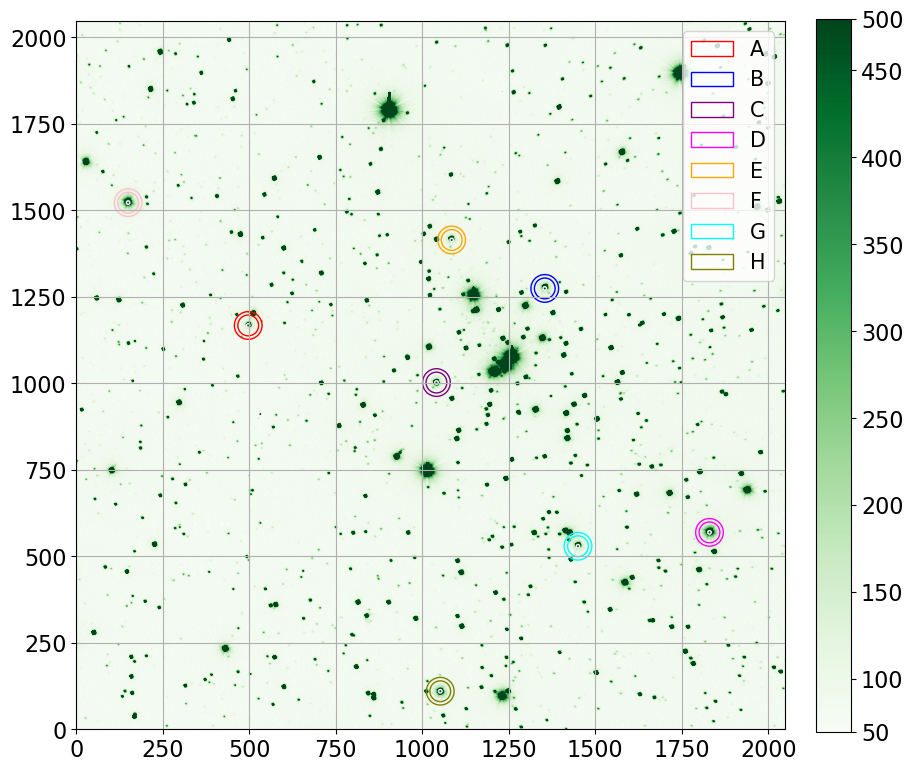

In [930]:
hdu = fits.open('Desktop/Obs_NB/reduced/otz_NGC6823/otzf_NGC6823_V/a159otzf.fits')
hdr = hdu[0].header
img_test = hdu[0].data

#A=(1045,1045)
#B=(1252,1225)
#C=(1365,1235)
#D=(1445,1185)

A=(497,1167)
B=(1354,1274)
C=(1041,1002)
D=(1830,569)
E= (1085,1414)
F= (150, 1522)
G= (1450, 529)
H= (1052, 110)
stan_star = [A,B,C,D,E,F,G,H]
colors = ['red', 'blue', 'purple', 'magenta', 'orange', 'pink', 'cyan', 'olive']
stan_star_name = ['A','B','C','D', 'E', 'F', 'G', 'H']

aperture = CircularAperture(stan_star, r=5)
annulus = CircularAnnulus(stan_star, r_in=30, r_out=40)

show_image(img_test.data, cmap='Greens')
aperture.plot(edgecolor='white')
for i in range(8):
    name=stan_star_name[i]
    annulus[i].plot(edgecolor=colors[i], label=name)
plt.legend(fontsize='small', prop={'size': 15})

In [931]:
ape_table_v = aperture_photometry(img_test.data, aperture)
ann_table_v = aperture_photometry(img_test.data, annulus)
ape_area = np.pi*(5**2)
ann_area = np.pi*(40**2 - 30**2)
bg_counts_v=[]
aperture_sums_v=[]
for i in range(8):
    bg_count = float(ann_table_v['aperture_sum'][i])/ann_area
    bg_counts_v.append(bg_count)
    aprert=ape_table_v['aperture_sum'][i]
    aperture_sums_v.append(aprert)
ins_magst=[]
for a,b in zip(aperture_sums_v, bg_counts_v):
    inst_mag = -2.5*np.log(a - ape_area*b)
    ins_magst.append(inst_mag)

In [932]:
ins_magst

[-33.90825676875096,
 -35.582940292611035,
 -34.73857979942027,
 -37.338870494595014,
 -34.214487821922376,
 -37.51761685494773,
 -34.6991250477719,
 -36.555727801398255]

In [933]:
#take magnitudes of stars in v and b filter
ins_mag_159v=np.array([-33.90825676875096, -35.582940292611035, -34.73857979942027, -37.338870494595014, -34.214487821922376, -37.51761685494773, -34.6991250477719, -36.555727801398255])
ins_mag_160b=np.array([-29.99598364134033, -33.17281890040216, -32.45729250332997, -36.09055415582952, -29.927119852066227, -36.29920478076562, -32.159060056063524, -34.85817234707683])
#calibrate stars using 
cal_v=[]
for i in ins_mag_159v:
    v=i-(1.5475683035228747*1.09)+44.718691+0.944460
    cal_v.append(v)
    
cal_b=[]
for i in ins_mag_160b:
    b=i-(0.3578707980089391*1.09)+44.772071+0.471208
    cal_b.append(b)

In [934]:
cal_vb = [a - b for a, b in zip(cal_b, cal_v)]

In [935]:
cal_vb

[4.78917140842082,
 3.28701967321906,
 3.158185577100493,
 2.1252146197756785,
 5.164266250866341,
 2.095310355192299,
 3.416963272718565,
 2.5744537353316117]

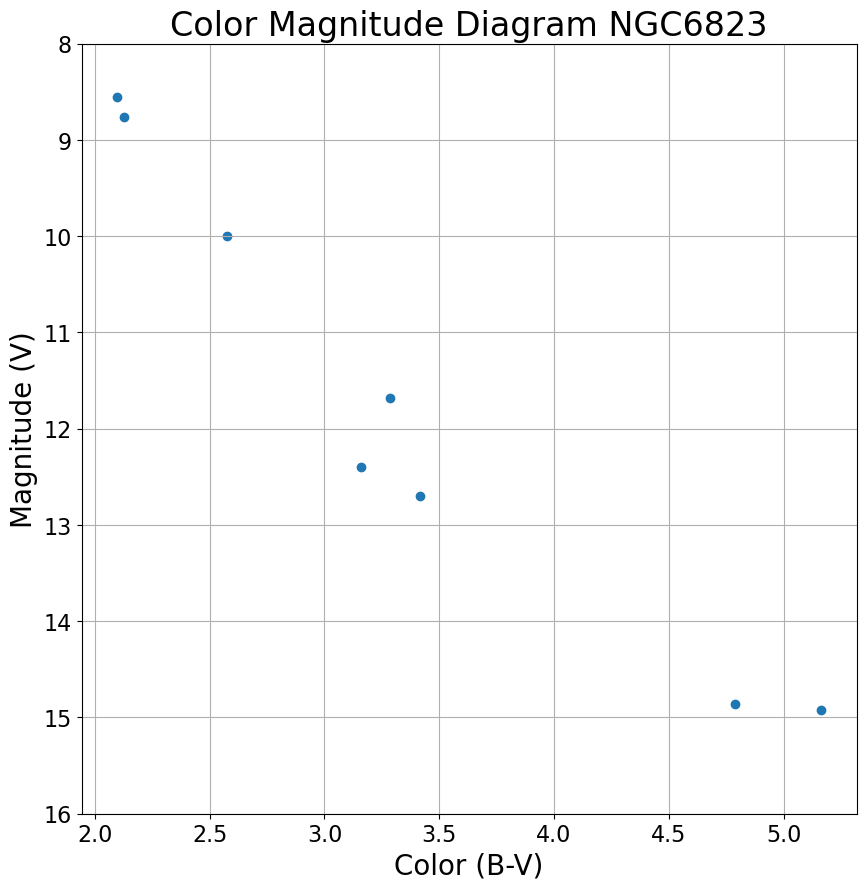

In [940]:
plt.figure(figsize=(10, 10))
#b_v5=np.array([0.505, 0.590, 0.618, 0.324]*5)
#y_v_r=np.array([43.17881640479018, 45.25613810899117, 44.270103606778406, 44.29553688729726])
plt.scatter(cal_vb, cal_b)
#m_bvrc, bvrc = np.polyfit(b_v2, v_ec(inst_magv, airmassv, land_mags*5), 1)
#plt.plot(b_v2, m_bvrc*b_v2 + bvrc, color='red') # Plot the fit line
plt.ylim(16, 8)
plt.xlabel(r'Color (B-V)')
plt.ylabel('Magnitude (V)')
plt.title('Color Magnitude Diagram NGC6823')
plt.show()